<p style="border:3px black solid; text-align: left; padding: 10px">✍ Представьте, что вы выполняете важный проект по машинному обучению. Конечно, вы можете делать всё самостоятельно, но если вы дополнительно узнаете мнение коллег, попросите ментора проверить ваши расчёты, найдёте как можно больше информации по вашей теме, то точно получите наилучший результат, ведь вы учтёте не только свои знания и выводы, но и информацию от других компетентных людей.

Составление прогнозов в машинном обучении может следовать такой же логике: один алгоритм часто даёт далёкий от желаемой точности прогноз, ведь у каждого метода есть свои ограничения, и в целом создание модели, которая строит очень близкие к реальности предсказания, — достаточно сложная задача. Однако если мы обучим на наших данных несколько моделей и обобщим результаты определённым образом, то сможем получить куда более точный результат.

Такой алгоритм решения задач машинного обучения называется $\color{green}{\text{ансамблем моделей}}$.

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>Ансамбль моделей</b> — это метод, в котором несколько алгоритмов (или вариации одного и того же) обучаются на одних данных, а итоговый прогноз строится на основе всех полученных от моделей прогнозов.

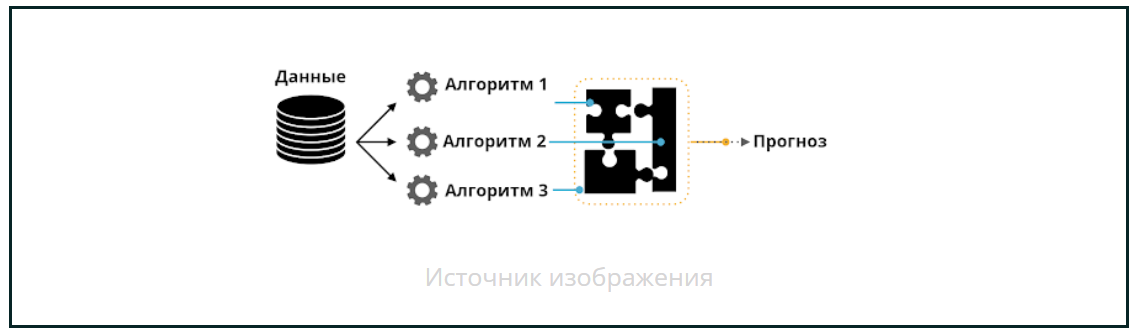

<p style="border:3px black solid; text-align: left; padding: 10px">Вы уже встречались с ансамблями, однако последние модули существенно обогатили ваши знания по математике, и теперь вы сможете изучить математическую основу и тонкости данных методов: особенности настройки параметров, различные библиотеки, нюансы применения тех или иных ансамблей. Это сделает вас более компетентными специалистами, глубоко понимающими суть применяемых методов.

## 2. Ансамбли моделей. Бутстреппинг. Бэггинг

<p style="border:3px black solid; text-align: left; padding: 10px">✍ В этом юните вы углубите свои знания ансамблей алгоритмов. Вы познакомитесь с тем, как формируются бутстреп-выборки, а также досконально изучите принцип бэггинга — самого простого варианта ансамблей.

В основе бэггинга лежит статистический метод, который называется $\color{бутстрепом (bootstrap)}{\text{green}}$. Идея бутстрепа заключается в генерации выборок размера n(бустер выборки) из исходного датасета размера N путём случайного выбора элементов с повторениями в каждом из наблюдений.

**Рассмотрим идею бутстрепа на элементарном примере.**

Пусть у нас есть выборка из 12 клиентов компании: у каждого из них есть свой ID (от 1 до 12) и какие-то характеристики. Мы можем создавать из данной выборки множество различных новых выборок клиентов с новым количеством человек (в данном случае представлены выборки из пяти человек). При этом информацию про одного и того же клиента можно использовать повторно.

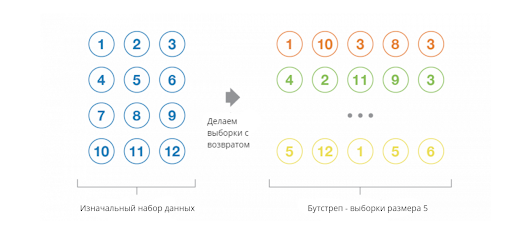

Это намного проще, чем находить новые выборки. По сути, мы собираем данные лишь единожды, а затем на их основе генерируем много выборок для обучения моделей. Это экономит огромные объёмы ресурсов и времени.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">При некотором приближении можно считать, что получающиеся выборки являются независимыми и репрезентативными — <b>это важное допущение</b>.

Выборки можно назвать **независимыми**, если результаты испытаний и измерения, осуществляемые для одной выборки, никак не влияют на результаты, получаемые на другой выборке.

**Репрезентативность** заключается в соответствии характеристик выборки всей генеральной совокупности.

Бутстреп-выборки часто используются для оценки различных статистических показателей, например разброса или доверительного интервала.

Если вычислять статистические оценки на нескольких независимых выборках, то мы можем, например, оценить их математическое ожидание или разброс. Приведём пример того, как это происходит с точки зрения математики.

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Допустим, у нас есть некоторая выборка x=(5,1,3,6,4), и мы хотим оценить для неё математическое ожидание. Например, это может быть выборка количества товаров, которые приобретали покупатели нашего магазина, и мы хотим найти ожидаемое количество товаров, которое купит случайный клиент.

$$E(x) =E(5,1,3,6,4) = \frac{1}{5} \cdot 5 + \frac{1}{5} \cdot1 + \frac{1}{5} \cdot3 + \frac{1}{5} \cdot6 + \frac{1}{5} \cdot4 = 1+0.2 +0.6 + 1.2 + 0.8 = 3.8$$

Однако это значение лишь на одной выборке, а мы хотели бы вычислить эту статистическую оценку на нескольких выборках и затем проанализировать разброс оценок.

Создаём несколько выборок с помощью бутстрепа и на каждой оцениваем математическое ожидание:

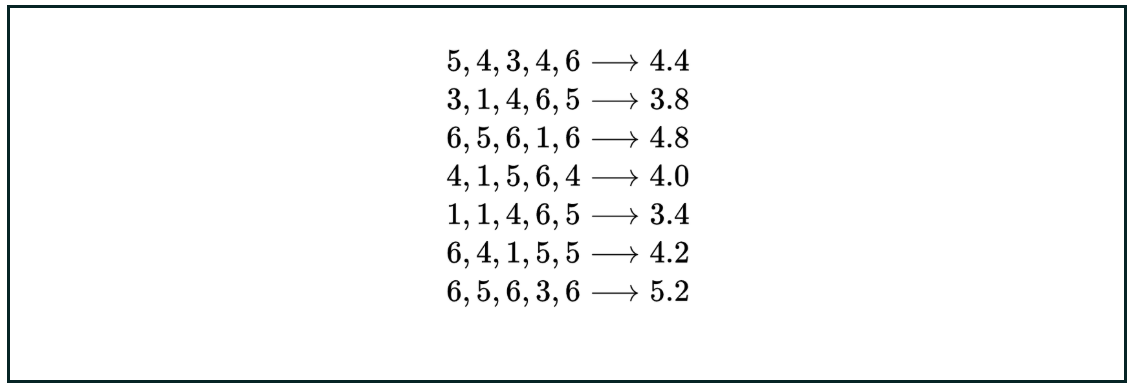

Получили ряд значений: 4.4, 3.8, 4.8, 4.0, 3.4, 4.2, 5.2

Теперь давайте найдём дисперсию для этого ряда. **См. Задание 2.2**

Таким образом, мы понимаем, что если мы будем создавать различные новые выборки и вычислять для них средние значения, то для полученных значений дисперсия будет равна найденному вами выше значению. **Мы узнали это, не собирая никаких новых данных.**

Формализуем только что проделанные действия математически:

1. Генерируем выборки. Необходимо создавать упорядоченные множества элементов, которые мы выбираем с возвратом(возможность брать элемент повторно) из некоторого имеющегося у нас множества: $$\left\{X_{1}, \ldots, X_{N}\right\}$$

2. Повторяем несколько раз процедуру генерации выборки: $$X_{b}^{*}=\left(X_{b 1}^{*}, \ldots, X_{b N}^{*}\right), \ где \ 1 \leqslant b \leqslant B$$

3. Считаем интересующую нас статистику по каждой выборке: $$T_{1}^{*}=T\left(X_{1}^{*}\right), \ldots, T_{B}^{*}=T\left(X_{B}^{*}\right)$$

4. Получаем бутстрепную оценку для интересующей нас статистики по этой выборке статистик. Например, для дисперсии она будет вычисляться так: $$\widehat{D}_{\text {boot }}=\frac{1}{B} \sum_{b=1}^{B} \left( T_{b}^{*} - \frac{1}{B} \sum_{b=1}^{B} T_{b}^{*}\right)^{2}$$

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Здесь символом * обозначена принадлежность к псевдовыборке;  — количество псевдовыборок.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Отлично, мы разобрались с тем, что такое метод бутстрепа. Запомните его идею — совсем скоро она пригодится вам для понимания алгоритма бэггинга.

<center>$\color{green}{\text{Bias и Variance}}$</center>

Прежде чем перейти непосредственно к ансамблям моделей, нам необходимо повторить bias-variance decomposition, или, как его называют по-русски, «разложение ошибки на смещение и разброс». Оно очень полезно для анализа ансамблей моделей.

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>Смещение</b> — это разница между математическим ожиданием для прогноза и реальным значением: $$Bias[\hat{f}(x)] = E[\hat{f}(x)]-y$$

- $E[\hat{f}(x)]$ —  математическое ожидание для прогноза,
- y — реальное значение функции

<p style="border:3px aquamarine solid; text-align: left; padding: 10px"><b>Смысл смещения</b> — способность получить лучшую среди всех возможных моделей, то есть максимально точные прогнозы.

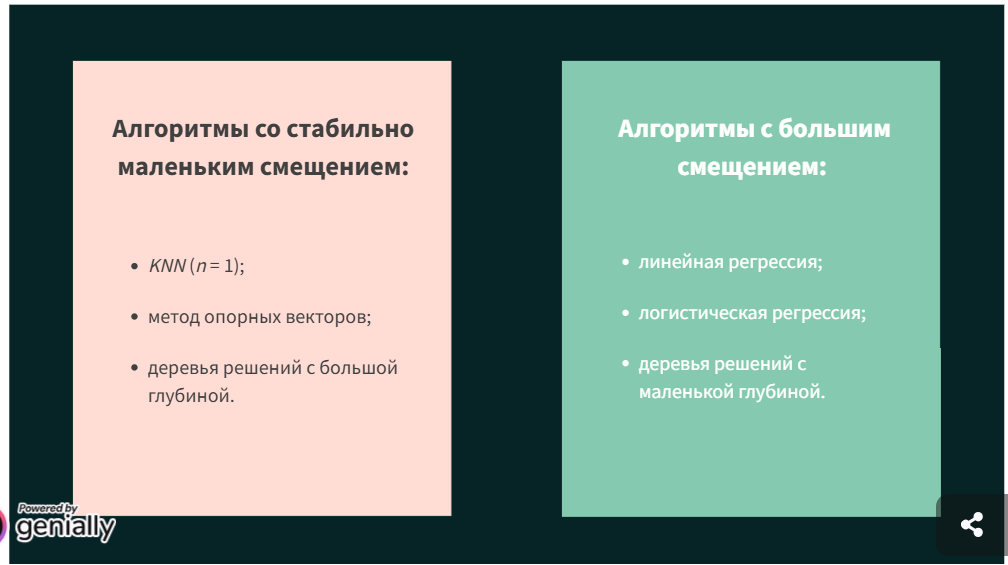

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Также значение смещения часто называют <b>ошибкой смещения</b> или <b>ошибкой из-за смещения</b>.<br>
Если у модели большое смещение, это значит, что ошибка будет достаточно велика из-за слишком сильного упрощения модели.

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>Разброс</b> — это величина разницы в результатах обучения модели на разных выборках: $$\operatorname{Var}[\hat{f}(x)]=\mathrm{E}\left[\left(\mathrm{E}[\hat{f}(x)]-\hat{f}(x)\right)^{2}\right]$$

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. С математической точки зрения разброс модели определяется как математическое ожидание квадрата разницы ожидаемого прогноза и реализованного прогноза модели.

Разброс характеризует устойчивость модели к изменениям в обучающей выборке:

- Если результат сильно зависит от того, какие объекты присутствуют в выборке, разброс будет большим.
- Если алгоритм работает стабильно вне зависимости от особенностей выборки, разброс будет маленьким.

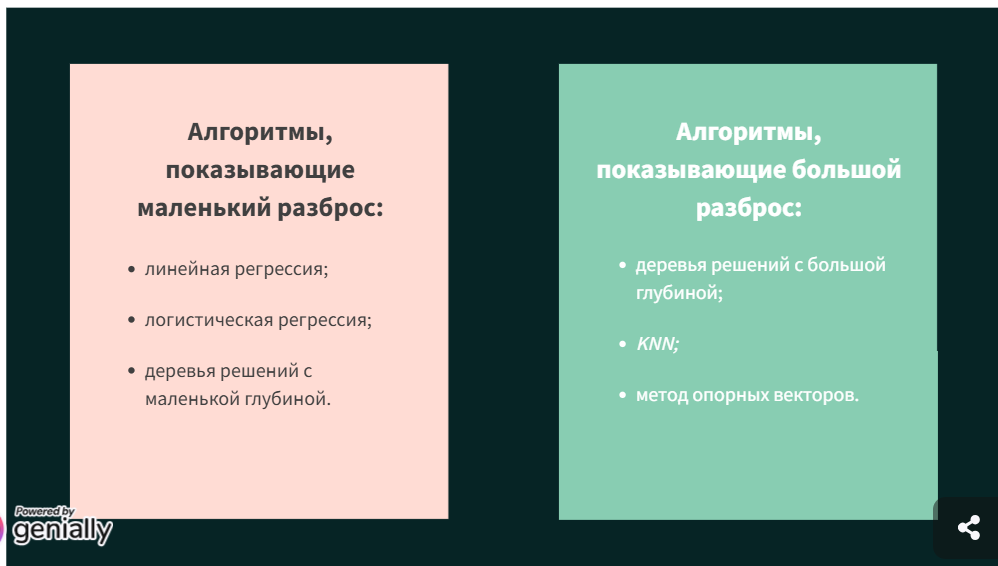

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Давайте рассмотрим разложение на смещение и разброс для линейной регрессии.

Пусть мы хотим предсказать значение $y$ по значениям вектора $x$. Тогда зависимость $y$ от $x$ можно записать следующим образом:

$$y=f(x)+\varepsilon$$

В качестве $f(x)$ здесь выступает истинная зависимость ответов $y$ от характеристик объекта $x$ — мы её не знаем и пытаемся предсказать с помощью модели. Предсказания обозначим как $\hat{f}(x)$. Символом  $\varepsilon$ обозначается случайная ошибка. Предполагается, что её математическое ожидание равно нулю — это просто шум.

Тогда давайте выразим ошибку для какого-то значения x. Она будет равняться математическому ожиданию для квадрата разницы между реальным и предсказанным значениями. По сути, это просто среднеквадратичная ошибка, записанная в немного иной форме:

$$\operatorname{Err}(x)=E\left[(y-\hat{f}(x))^{2}\right]$$

Также мы можем разложить среднеквадратичную ошибку следующим образом:

$$\operatorname{Err}(x)=(E[\hat{f}(x)]-y)^{2}+E\left[(\hat{f}(x)-E[\hat{f}(x)])^{2}\right]+\sigma_{\varepsilon}^{2}$$

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">$$\operatorname{Err}(x)=\operatorname{Bias}^{2}+Variance+Irreducible Error$$

Доказательство равенства: Рассмотрим вывод этого разложения, наглядно представленный в [Википедии](https://ru.wikipedia.org/wiki/%D0%94%D0%B8%D0%BB%D0%B5%D0%BC%D0%BC%D0%B0_%D1%81%D0%BC%D0%B5%D1%89%D0%B5%D0%BD%D0%B8%D1%8F%E2%80%93%D0%B4%D0%B8%D1%81%D0%BF%D0%B5%D1%80%D1%81%D0%B8%D0%B8).

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px"> Мы получили, что наша ошибка — это сумма квадрата смещения, разброса и неустранимой случайной ошибки. Теперь мы понимаем, из чего состоит ошибка модели. Такое представление помогает нам исследовать с теоретической точки зрения некоторые алгоритмы машинного обучения и часто используется при изучении ансамблей.

Рассмотрим иллюстрацию того, как сдвиг и разброс влияют на качество предсказания. На рисунке ниже вы видите цель (красный круг), в которую мы хотим попасть.

Есть четыре ситуации:

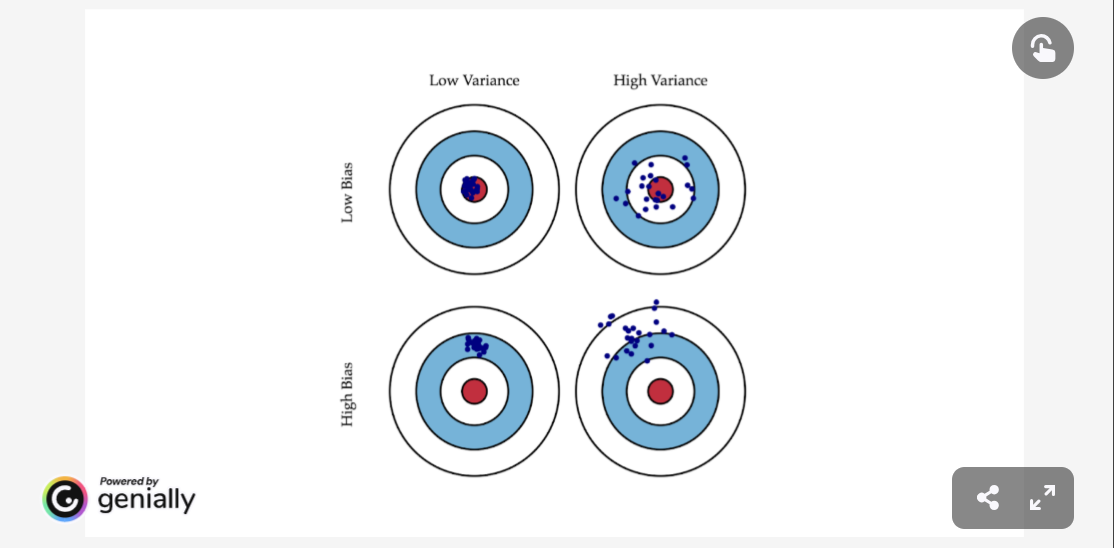

В моделях машинного обучения принцип тот же, только в качестве центра мишени выступает минимально возможная ошибка.

Когда говорят про разложение на bias и variance, то часто упоминают некую точку баланса:

- Если модель очень простая, с маленьким количеством параметров, то, скорее всего, у неё будет очень большое смещение, но маленький разброс.
- Если модель очень сложная, со множеством параметров, у неё будет большой разброс и маленькое смещение.

Схематично эти зависимости можно изобразить следующим образом (это схема не для конкретной модели, а лишь иллюстрация тенденций):

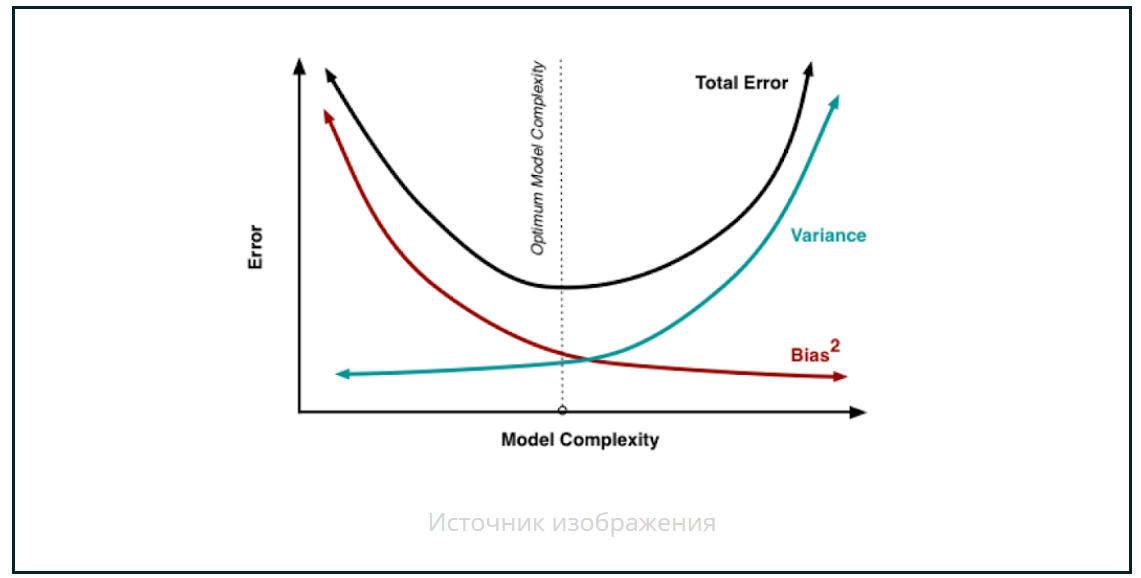

На графике выше по оси абсцисс отложена сложность модели (Model Complexity), а по оси ординат — ошибка (Error). Также изображены смещение (), разброс (Variance) и ошибка (Total Error — сумма смещения и разброса).

Как вы можете видеть, есть некоторая оптимальная точка, в которой разброс и смещение небольшие, а ошибка минимальна. Именно эта точка нас и интересует.

<center>$\color{green}{\text{Бэггинг}}$</center>

Перейдём к понятию $\color{green}{\text{бэггинг}}$.

При построении моделей всегда есть вероятность, что при обучении на других данных получились бы другие результаты. Для того чтобы нивелировать такую вероятность, можно использовать бэггинг.

Его идея состоит в том, что мы берём несколько независимых моделей(обученных на независимых выборках) и усредняем полученные по ним результаты. Таким образом мы получаем модель, имеющую меньший разброс, так как при её построении мы учли несколько моделей.

Как уже было сказано, в реальности получить много независимых выборок слишком сложно, так как найти столько данных обычно невозможно. Поэтому мы используем бутстреп-выборки, о которых говорили в начале юнита.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Важно отметить, что при бэггинге размер каждой бутстреп-выборки должен <b>совпадать с размером исходной выборки<b>.

При бэггинге каждая бутстреп-выборка создаётся путём выбора случайных наблюдений с возвращением из исходной выборки. Размер каждой бутстреп-выборки должен совпадать с размером исходной выборки по следующим причинам:

- **Сохранение информации**. Сохранение размера исходной выборки позволяет нам сохранять информацию о разнообразии данных и избежать потери информации.
- **Реплицируемость**. Использование бутстреп-выборки с таким же размером, как у исходной выборки, позволяет нам воспроизводить результаты. Если мы каждый раз создаём бутстреп-выборки разного размера, то результаты могут варьироваться, что затруднит сравнение и интерпретацию результатов.
- **Стабильность оценок**. Размер бутстреп-выборки, совпадающий с размером исходной выборки, способствует стабильности оценок. Больший размер бутстреп-выборки обеспечивает более точные оценки, но увеличивает вычислительную сложность, поэтому размер бутстреп-выборки обычно выбирается равным размеру исходной выборки для достижения баланса между точностью и вычислительной эффективностью.

Схематично процесс бэггинга можно представить следующим образом:

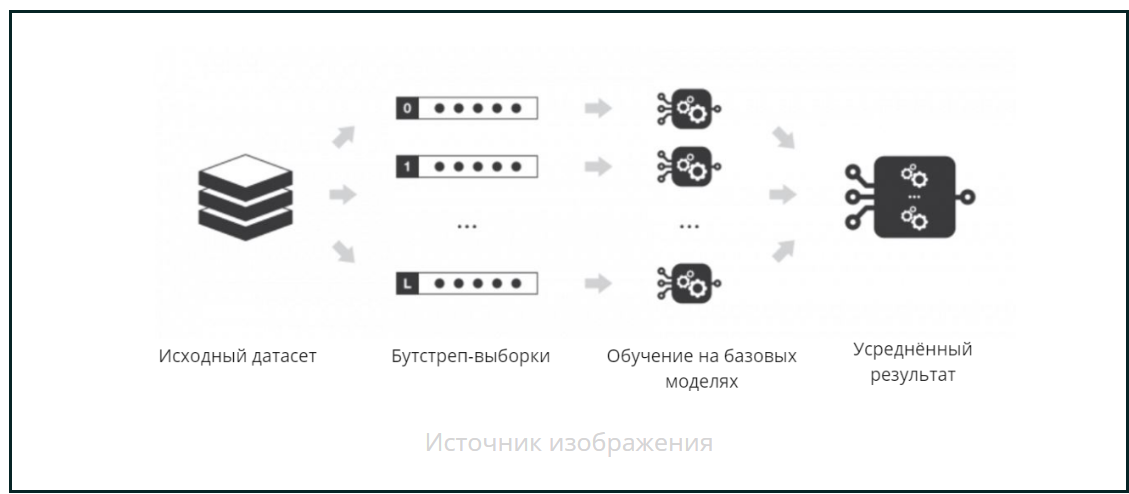

Пусть у нас есть некоторая выборка, и мы с помощью бутстрепа генерируем из неё ещё $B$ выборок:

$$X_{1}, ..., X_{B}$$

После этого мы определяем много базовых алгоритмов (всего $B$ моделей — по числу выборок) и обучаем каждый базовый алгоритм $a_{i}(x)$ на своей выборке. После этого получаем итоговый результат:

$$a(x)=\frac{1}{B} \sum_{i=1}^{B} a_{i}(x)$$

- Если мы рассматриваем задачу **классификации**, то, по сути, модели «голосуют» за свой класс.
- Если мы рассматриваем задачу **регрессии**, то результат — просто среднее арифметическое прогнозов по всем моделям.

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Теперь посмотрим, <b>насколько применение бэггинга поможет нам улучшить качество модели</b>.

Представим, что мы хотим использовать бэггинг для решения задачи регрессии и берём для этого $K$ базовых алгоритмов:

$$a_{1}(x), ..., a_{K}(x)$$

Конечно, если для каждого объекта известно значение целевой переменной, мы можем вычислить ошибку для каждой модели:

$$\varepsilon_{i}(x)=a_{i}(x)-y(x), i=1, \ldots, K$$

Также мы можем выразить математическое ожидание квадратичной ошибки (т. е., по сути, среднеквадратичную ошибку): $$\mathbb{E}_{x}\left[\left(a_{i}(x)-y(x)\right)^{2}\right]=\mathbb{E}_{x}\left[\varepsilon_{i}^{2}(x)\right]$$

Ошибка здесь обозначается как $\varepsilon_{i}(x)$.

Тогда, если мы усредним значение ошибки по всем моделям регрессии, то получим следующее:

$$\mathbb{E}_{1}=\frac{1}{K}\mathbb{E}_{x}[\sum_{i=1}^{K}\varepsilon_{i}^2(x_j)]$$

где $\sum_{i=1}^{K}\varepsilon_{i}^2(x_j)$ — сумма квадратичных ошибок по предсказаниям разных моделей (алгоритмов $a_i$) для одного конкретного наблюдения $x_j$.

Будем считать, что математическое ожидание для всех ошибок равно нулю (то есть нет какого-то систематического смещения ошибок, и они случайные) и что все ошибки независимы друг от друга (то есть их коэффициент корреляции равен нулю):

$$\begin{aligned} \mathbb{E}_{x} \varepsilon_{i}(x) &=0 \\ \mathbb{E}_{x} \varepsilon_{i}(x) \varepsilon_{j}(x) &=0, i \neq j \end{aligned}$$

Теперь определим регрессионную функцию, которая будет брать ответы от всех обученных нами регрессионных моделей и просто усреднять их:

$$f(x)=\frac{1}{K} \sum_{i=1}^{K} a_{i}(x)$$

Теперь найдём для этой модели среднеквадратичную ошибку. Выразим её через математическое ожидание:

$$\mathbb{E}_{K}=\mathbb{E}_{x}\left(\frac{1}{K} \sum_{i=1}^{K} a_{i}(x)-y(x)\right)^{2}$$

Упростим часть внутри скобок, воспользовавшись введённым ранее утверждением о том, что $\mathbb{E}_{x}\left[\left(a_{i}(x)-y(x)\right)^{2}\right]=\mathbb{E}_{x}\left[\varepsilon_{i}^{2}(x)\right]$, и получим следующее:

$$\mathbb{E}_{x}\left[\left(a_{i}(x)-y(x)\right)^{2}\right]=\mathbb{E}_{x}\left[\varepsilon_{i}^{2}(x)\right]$$

$$=\mathbb{E}_{x}\left(\frac{1}{K} \sum_{i=1}^{K} \varepsilon_{i}\right)^{2}$$

После этого вынесем за скобку $\frac{1}{K}$, а также возведём внутреннюю часть скобки в квадрат:

$$=\frac{1}{K^{2}} \mathbb{E}_{x}\left(\sum_{i=1}^{K} \varepsilon_{i}^{2}(x)+\sum_{i \neq j} \varepsilon_{i}(x) \varepsilon_{j}(x)\right)$$

Ранее мы уже выяснили, что $\sum_{i \neq j} \varepsilon_{i}(x) \varepsilon_{j}(x)$ равняется нулю, так как все ошибки независимы. Сокращаем выражение и получаем в итоге:

$$\mathbb{E}_{K}=\frac{1}{K}\mathbb{E}_{1}$$

Получается, что путём усреднения предсказаний линейных регрессий мы смогли уменьшить среднеквадратичную ошибку в $K$ раз.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Однако тут важно отметить, что при решении прикладных задач эффект будет не таким выраженным, так как здесь мы использовали предположение о полной независимости ошибок, а в реальной жизни такое случается редко.

Также, чтобы иметь полное представление о характеристиках рассматриваемого алгоритма, давайте вспомним про разложение ошибки на смещение и разброс.

Доказано, что бэггинг не ухудшает показатель смещения модели, то есть смещение у ансамбля ровно такое же, как и у одного базового алгоритма.

В общем случае разброс бэггинга будет выражаться следующим образом:

$$\frac{1}{K}\left(\operatorname{Var} a_{n}(x)\right)+\operatorname{Cov}\left(a_{n}(x), a_{m}(x)\right)$$

В данном выражении $\operatorname{Cov}$ — это матрица ковариаций, через $a_{n}(x)$ обозначен один из базовых алгоритмов, а $a_{m}(x)$ — другой базовый алгоритм.

Из этого следует, что если модели (в данной формуле — базовые модели $a_{n}(x)$ и $a_{m}(x)$) независимы, то разброс для ансамбля типа бэггинг будет в $K$ раз меньше, чем разброс у отдельной модели.

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Резюмируем:<br>
1. Бэггинг даёт уменьшение ошибки в $K$ раз по сравнению с одиночной моделью.<br>
2. Бэггинг не уменьшает смещение по сравнению с одиночной моделью.<br>
3. Бэггинг уменьшает разброс в $K$ раз по сравнению с одиночной моделью

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Важно отметить, что эти утверждения выведены и доказаны теоретически и будут выполняться на практике только в том случае, если между ошибками нулевая корреляция.

## 3. Случайный лес

<p style="border:3px black solid; text-align: left; padding: 10px">✍ В предыдущем юните мы поговорили о бэггинге — одном из видов ансамблей моделей. В этом юните мы будем разбирать модификацию бэггинга — случайный лес.

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Допустим, у нас есть набор данных с фруктами, для которого мы хотим решить задачу классификации. Известны цвет, диаметр, форма, время созревания и другие особенности каждого объекта.<br>
Наша задача состоит в том, чтобы построить модель классификации, которая в будущем сможет по характеристикам фрукта определять его вид.

Строим три решающих дерева, которые делают предсказания следующим образом:

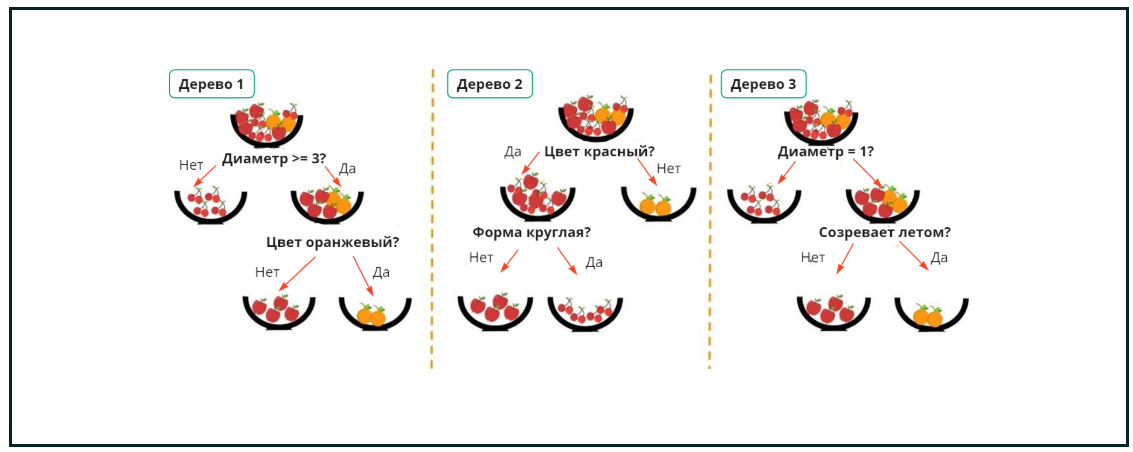

Появляется новый фрукт, про который мы пока ничего не знаем, кроме его признаков:

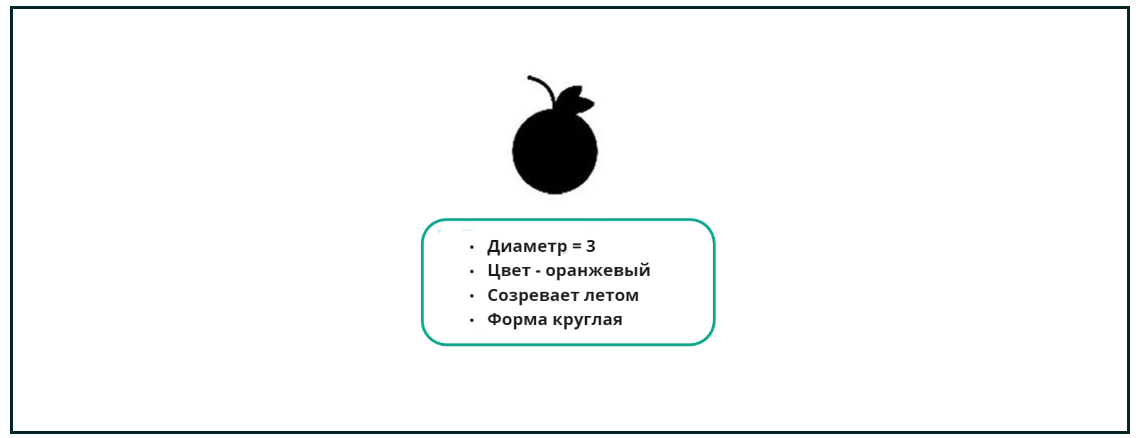

Наш случайный лес, состоящий из трёх деревьев, будет классифицировать этот фрукт следующим образом:

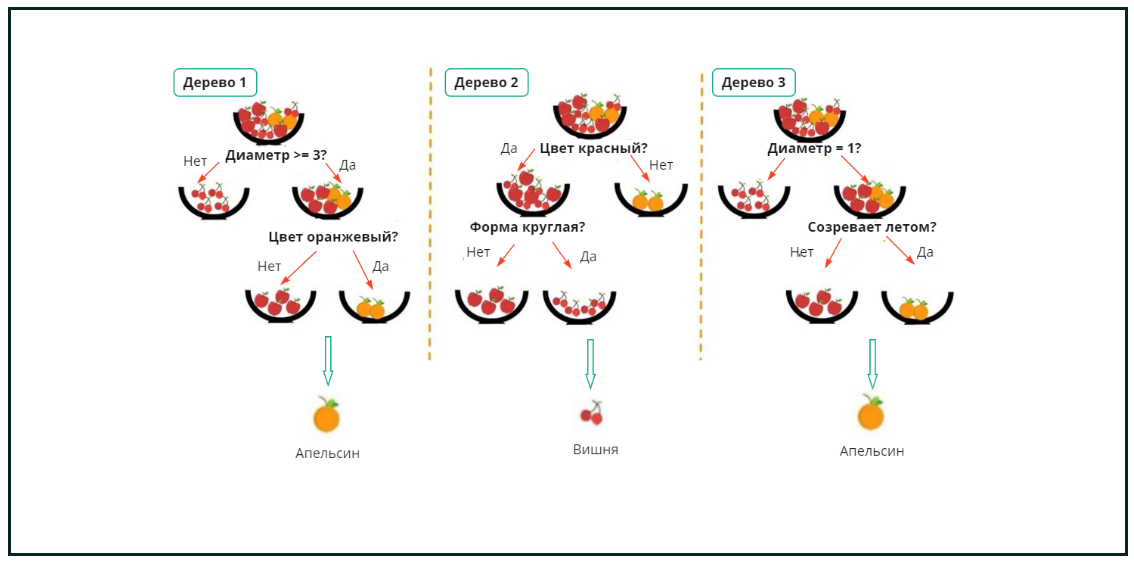

Мы видим, что два дерева голосуют за то, что это апельсин, и одно дерево голосует за вишню. Тогда большинством голосов мы решаем, что это апельсин.

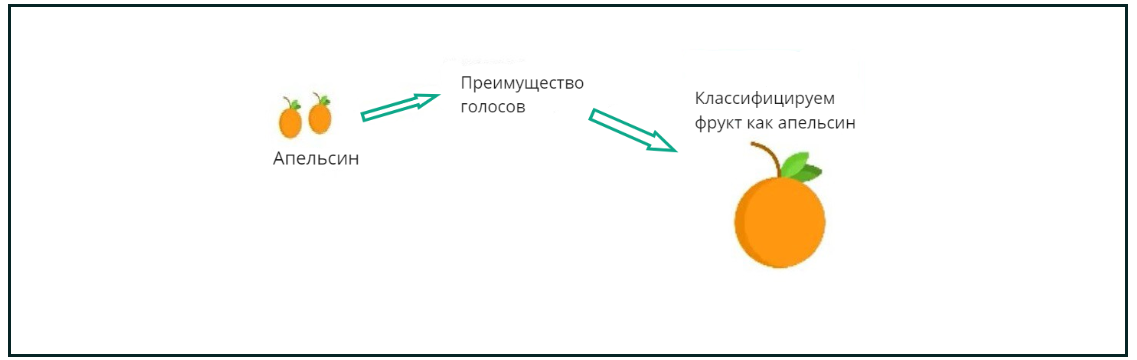

Вот и всё, мы решили задачу классификации с помощью случайного леса.

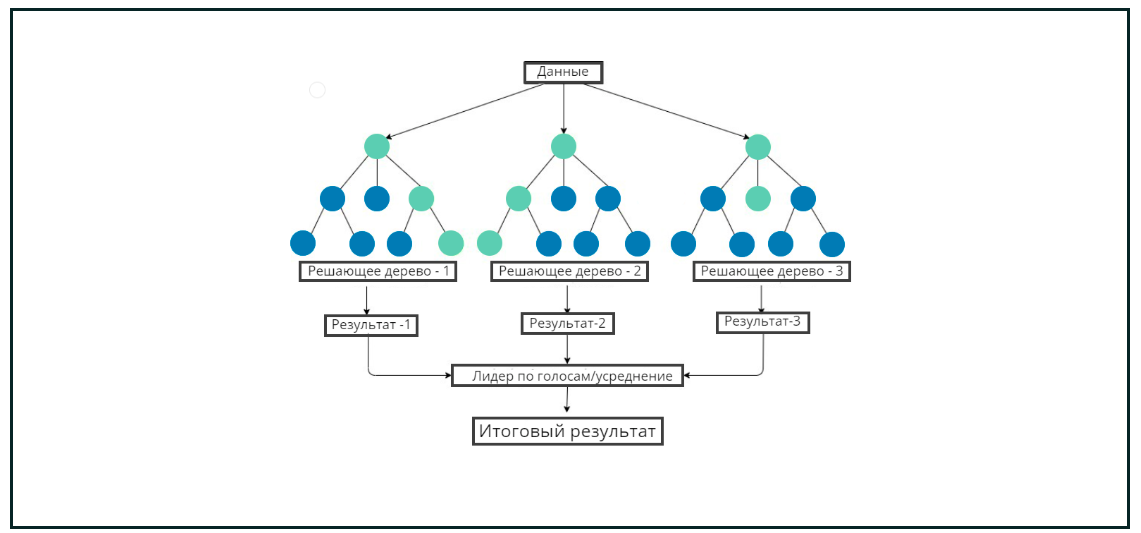

Есть какое-то количество решающих деревьев, каждое из которых мы обучаем на некоторой подвыборке из данных. Получив вердикты от всех моделей, определяем итоговый результат для каждого объекта.

**Для регрессии** правило формирования итогового результата формулируется следующим образом:

$$f(x)=\frac{1}{K} \sum_{i=1}^{K} a_{i}(x)$$

- $K$ — количество моделей,
- $a_i(x)$ — алгоритм решающего дерева,
- $f(x)$ — значение финального предсказания ансамбля.

Это означает, что мы просто находим среднее арифметическое для всех полученных предсказаний.

Правило формирования итогового результата **для классификации**:

$$f(x)=\arg \max _{y \in \mathbb{Y}} \sum_{i=1}^{K}\left[a_{i}(x)=y\right]$$

Здесь деревья просто голосуют за некоторый класс, и объекту присваивается метка класса, за который было отдано наибольшее количество голосов.

Давайте рассмотрим алгоритм реализации случайного леса.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Одно из важных понятий, которое здесь появляется, — это <b>метод случайных подпространств</b>, который используется для построения ансамблей моделей.

Кратко опишем его принцип:

1. Отбираем обучающую выборку.
2. Определяем число моделей, которые войдут в ансамбль.
3. Для каждой модели берём не все признаки, а только часть из них и формируем выборку с использованием случайно выбранного набора признаков.
4. Объединяем все результаты и определяем итоговое решение по объектам.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px"><b>Обратите внимание на важную особенность</b>: здесь выбирается не только обучающая выборка, но ещё и случайная выборка из признаков.

Алгоритм случайного леса в таком контексте реализуется следующим образом:

1. Для того чтобы построить $i$-е дерево леса, из обучающей выборки $X$ берём случайную подвыборку $X_i$ того же размера, что и вся обучающая выборка.
2. После этого в каждой вершине каждого дерева из $M$ возможных признаков выбираем случайную группу признаков объёма $L$. Для выбранных признаков ищем оптимальное разбиение. Рекомендуется использовать $L=\sqrt{M}$ в задачах классификации и $\frac{M}{3}$ — в задачах регрессии.
3. Для получения предсказания необходимо воспользоваться обычным принципом бэггинга: взять усреднённый ответ в случае регрессии или самый популярный класс — для классификации.

В контексте случайного леса важно обратить внимание на **несколько ключевых аспектов**:

**1. Переобучение**
Случайный лес может переобучаться, однако это никак не связано с количеством деревьев. Наоборот, с ростом числа деревьев модель становится всё более эффективной в плане корректных прогнозов. На анимации ниже наглядно показано, что случайный лес не переобучается, а [совершенствует своё предсказание](https://lms-cdn.skillfactory.ru/assets/courseware/v1/825d6b9296ccef04ea5207300fdc3e0a/asset-v1:SkillFactory+DST-3.0+28FEB2021+type@asset+block/MATHML_md9_3_7.gif).
Здесь мы видим пространство признаков с объектами, которые относятся к двум классам ($\color{red}{\text{красные}}$ точки и $\color{blue}{\text{синие}}$ точки). Мы пытаемся построить разделяющую их поверхность, которая корректируется по ходу увеличения числа деревьев (счётчик количества деревьев расположен сверху).

**2. Out-of-Bag Error**

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>Ошибка Out-of-Bag</b> — это способ оценить качество случайного леса.

Предположим, что в нашем случайном лесу пять решающих деревьев, и наша обучающая выборка выглядит следующим образом:

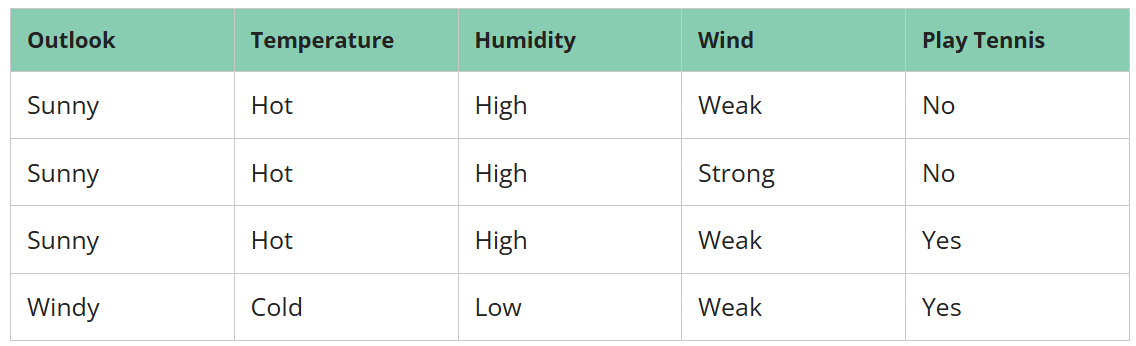

В выборку внесены погодные условия и итоговое решение — подходит ли день для игры в теннис. Итоговое решение при одинаковых погодных условиях может отличаться, так как на него могли повлиять и другие факторы.

Для первого дерева мы делаем такую подвыборку *(Bootstrap Sample)*:

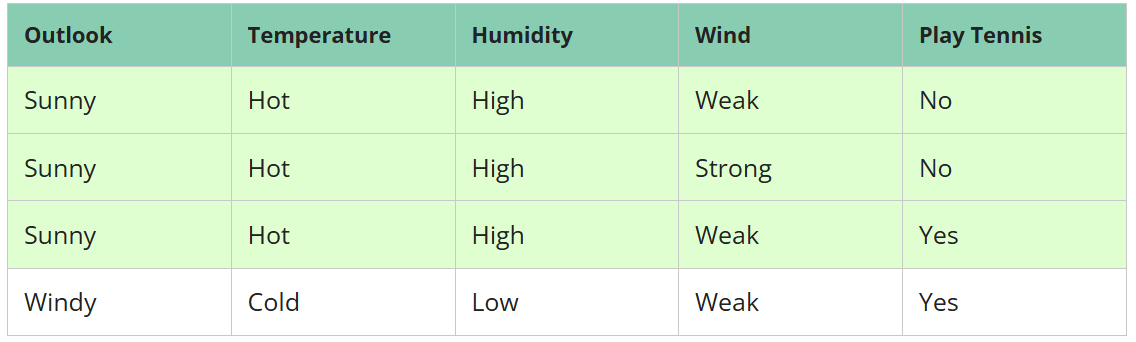

Тогда неучтённая часть выборки носит название подвыборки *Out-of-Bag (Out-of-Bag Sample)*:

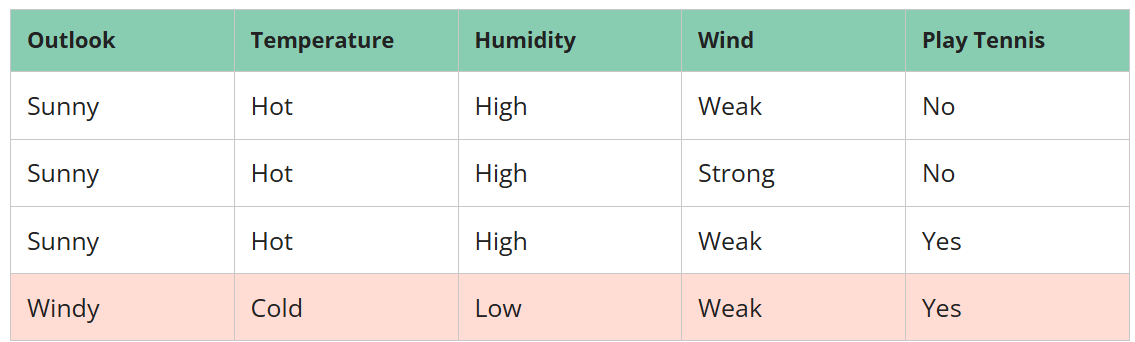

После того как все деревья будут обучены, эта подвыборка будет передана всем деревьям, для которых она не входила в бутстреп-выборку, для формирования прогноза. Допустим, это были деревья под номерами 1, 3 и 5:

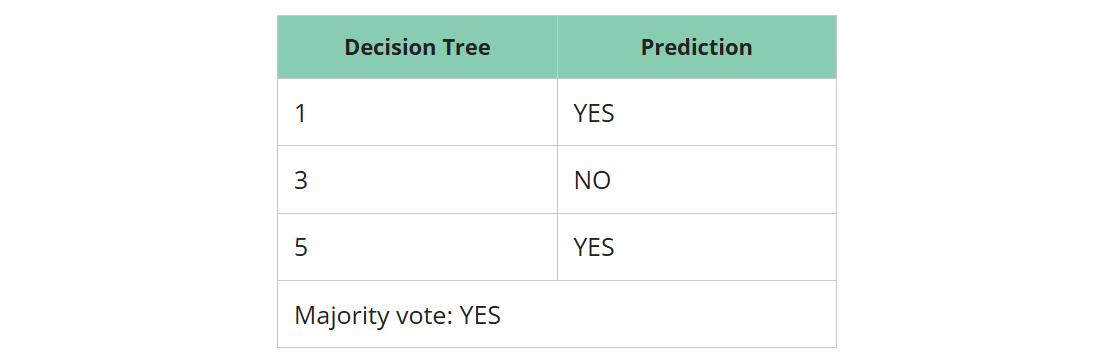

Мы видим, что большинство деревьев проголосовало, что день подходит для игры в теннис, то есть окончательный прогноз для этого объекта — YES. Это совпадает с реальной меткой. Значит, на этом наблюдении алгоритм дал верный прогноз.

Таким же образом все объекты изначальной выборки проходят через все деревья, в подвыборку которых они не попали, и для каждого объекта осуществляется предсказание.

Интересно, что можно доказать, что такие объекты составляют примерно 36.8 % от объёма подвыборки, то есть каждое дерево обучается на подвыборке, в которой в среднем 63.2 % уникальных наблюдений.

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Пусть в нашей выборке есть $N$ наблюдений. На каждом шаге каждое наблюдение попадает в выборку с вероятностью $\frac{1}{N}$. Тогда вероятность того, что оно не попадает в выборку, — $1-\frac{1}{N}$. Причём если выборка формируется $N$ раз, то вероятность становится равна $(1-\frac{1}{N})^N$. Теперь можно применить пределы, чтобы получить итоговый процент: $$\displaystyle \lim_{N \to \infty }(1-\frac{1}{N})^N=e^{-1}=0.368$$

**Примечание**. Данный переход напрямую следует из второго замечательного предела. К сожалению, эта часть математического анализа выходит за пределы нашего курса, однако если вам интересно изучить её подробнее, рекомендуем ознакомиться с этим [материалом](https://www.mathprofi.ru/zamechatelnye_predely.html).

Получается почти 37 %. Out-of-Bag-оценка — это как раз усреднённая оценка базовых алгоритмов на этих ~37% данных, на которых они не обучались.

Итак, для того чтобы найти *out-of-Bag*-оценку:

1. Для каждого объекта $X_i$ получаем предсказания всех деревьев $a_b$, обучавшихся на бутстреп-выборках $X_b$, не содержащих $x_i$.
2. Усредняем эти предсказания.
3. Находим значение ошибки для усреднённого предсказания.
4. Усредняем значение функционала ошибки для всех объектов выборки.
Строго математически это можно записать следующим образом:$$\mathrm{OOB}= \frac{1}{N}\sum_{i=1}^{N} L\left(y_{i}, \frac{1}{\sum_{b=1}^{B}\left[x_{i} \notin X_{b}\right]} \sum_{b=1}^{B}\left[x_{i} \notin X_{b}\right] a_{b}\left(x_{i}\right)\right)$$

**3. Значимость признаков**

Разумеется, нам всегда интересно узнать, какие признаки сильнее всего влияют на результат. Случайный лес даёт нам такую возможность. Посмотрим на схематичное изображение решающего дерева:

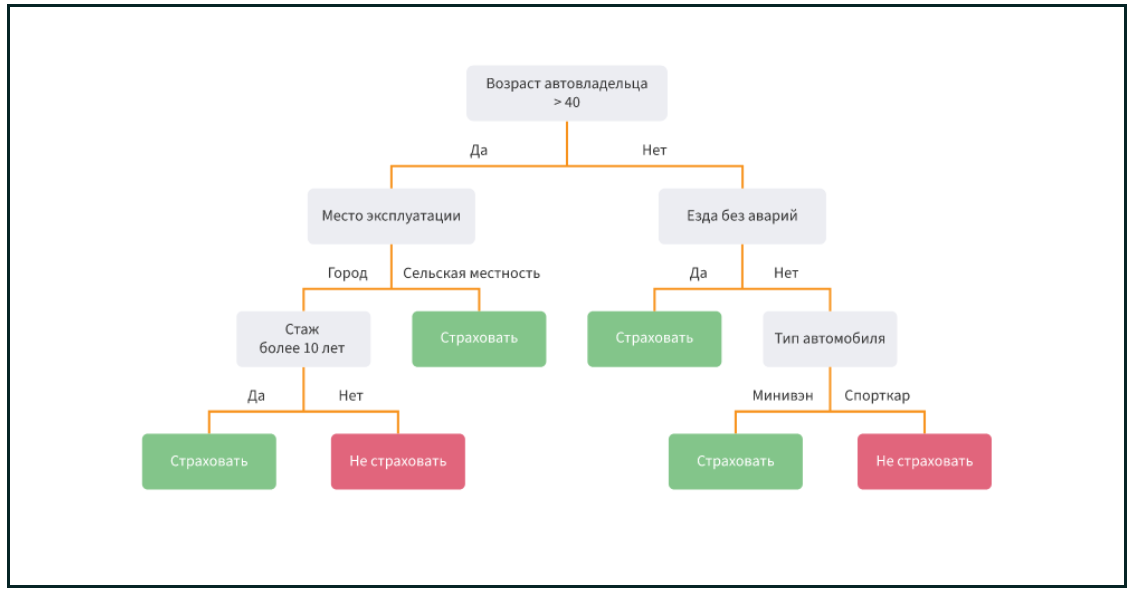

Мы видим, что признак «возраст автовладельца > 40 лет» важнее, чем, например, тип автомобиля. Нам хотелось бы не только узнать самый важный признак, но и в целом проранжировать все признаки модели.

В случайном лесе мы строим много деревьев, и чем в среднем выше какой-то признак находится в деревьях, тем он важнее.

В предыдущем модуле мы разобрали решающие деревья, а в этом — бэггинг и случайный лес. Давайте попробуем сравнить эти алгоритмы и понять, какой из них является более эффективным и даёт бóльшую прогностическую точность.

Реализуем три варианта моделей для случайно сгенерированных данных:

- решающее дерево c глубиной 15;
- бэггинг с десятью решающими деревьями:
 - по одному — глубины 11, 14, 15, 16,
 - четыре — глубины 13,
 - два — глубины 12;
- случайный лес с десятью решающими деревьями:
 - по одному — глубины 12, 18,
 - два — глубины 16,
 - шесть — глубины 13.

Попробуем оценить качество в каждом случае. Результаты представлены на графиках ниже.

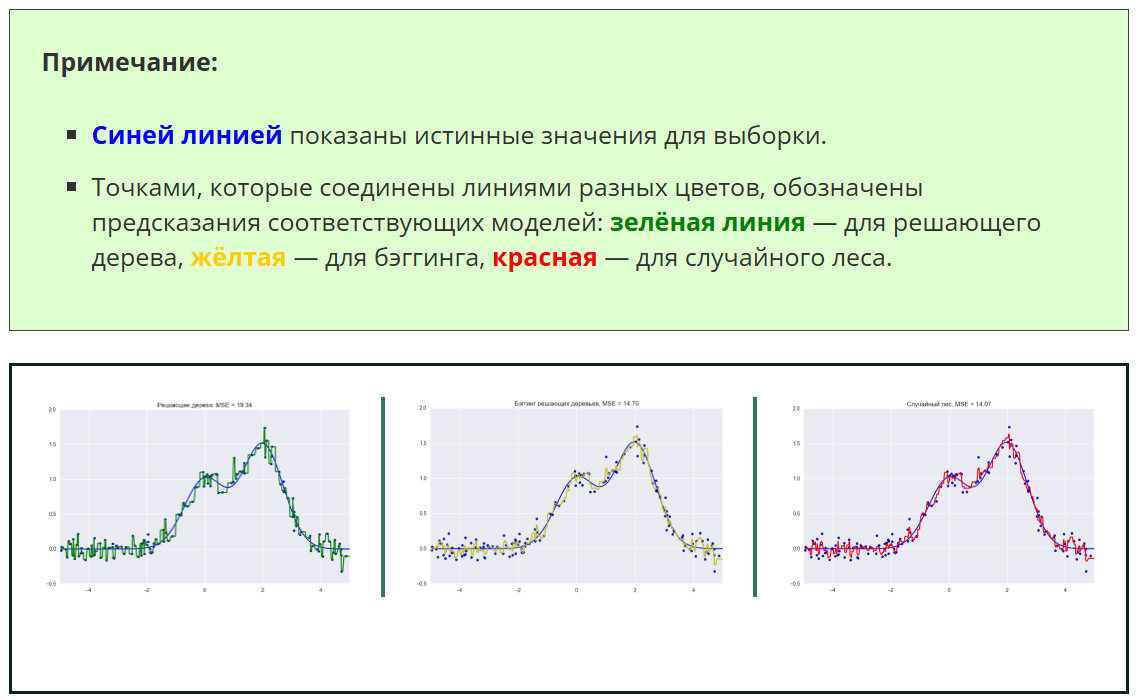

Из графиков можно увидеть, что ошибка для алгоритма бэггинга над решающими деревьями заметно меньше, чем ошибка для одного решающего дерева. Численные результаты подтверждают это. Случайный лес в данном случае обгоняет по эффективности бэггинг над решающими деревьями (однако это не является правилом, и с другими данными может получиться другой результат).

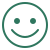

- Очень высокая точность предсказания (это один из самых эффективных алгоритмов).
- Данные не обязательно масштабировать: случайный лес не чувствителен к масштабированию и в принципе к любым монотонным преобразованиям, поэтому в таких манипуляциях нет смысла.
- Нет чувствительности к выбросам из-за формирования случайных выборок.
- Не требуется тщательно настраивать множество параметров. Даже если реализовывать алгоритм с настройками по умолчанию, результат будет лучше, чем у большинства других моделей.
- Позволяет оценить значимость отдельных признаков.
- Может эффективно работать с несбалансированными классами.
- Показывает высокую точность на данных с большим количеством пропусков.

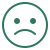

- Плохо работает с разрежёнными признаками (т. е. с такими, у которых преимущественно нулевые значения). Это может сказываться, к примеру, на качестве анализа текстов.
- Сложно интерпретировать результаты.

##   4. Случайный лес. Практика

#### См.  MATH&ML/MATH&ML. Практика оцениваемая ментором/MATH&ML-9 Случайный лес. Практика

## 5. Бустинг

<p style="border:3px black solid; text-align: left; padding: 10px">✍ В предыдущих юнитах мы познакомились с одним из видов ансамблевых методов — бэггингом. Пришло время поговорить ещё об одном типе ансамблей — бустинге.

В целом, идеи бустинга и бэггинга очень похожи: в обоих случаях мы берём слабые модели и объединяем их для получения более качественного прогноза. Однако есть одно ключевое различие:

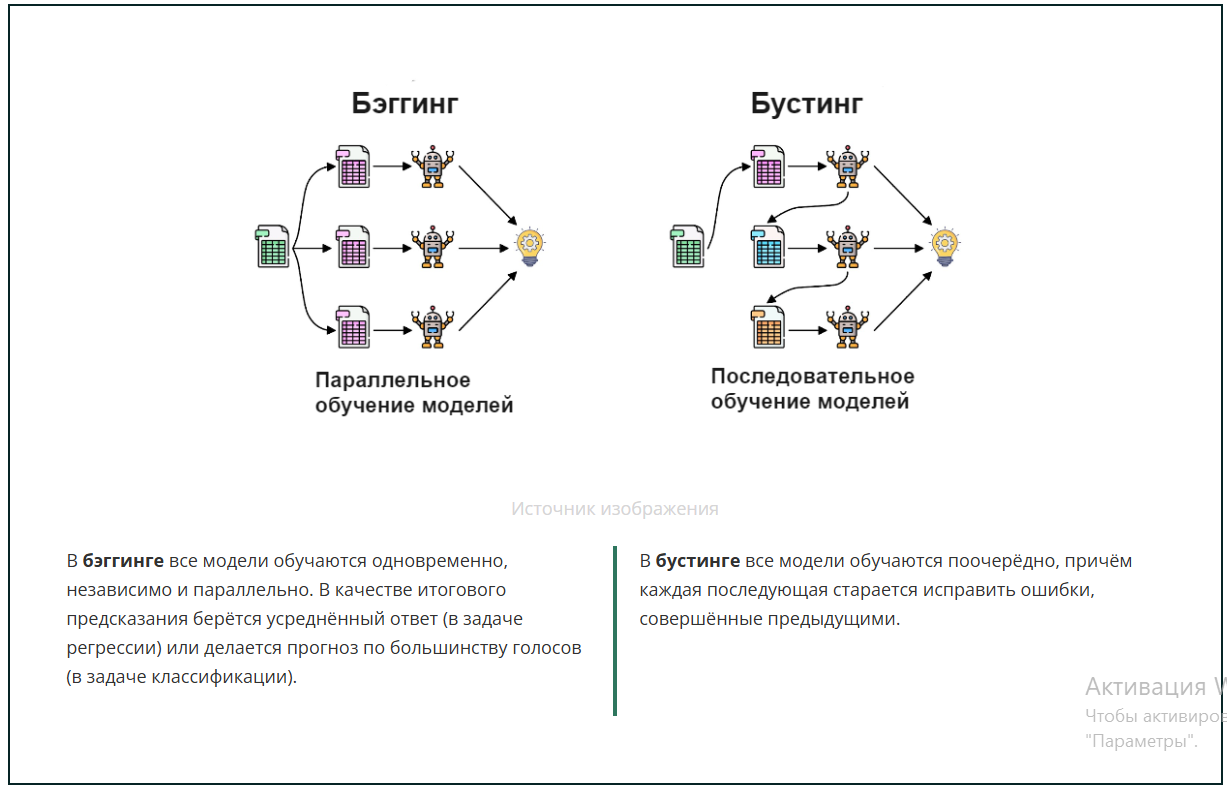

В примере ниже гольфист сначала пытается забить мяч в лунку в точкe $y$, но добирается только до координаты $f_1 (x)$. Здесь отверстие в точке $y$ является целевой переменной. После переоценки направления и расстояния до лунки после каждого удара игрок несколько раз бьёт по мячу, более мягко направляя его к лунке, и так до тех пор, пока не попадёт в лунку.

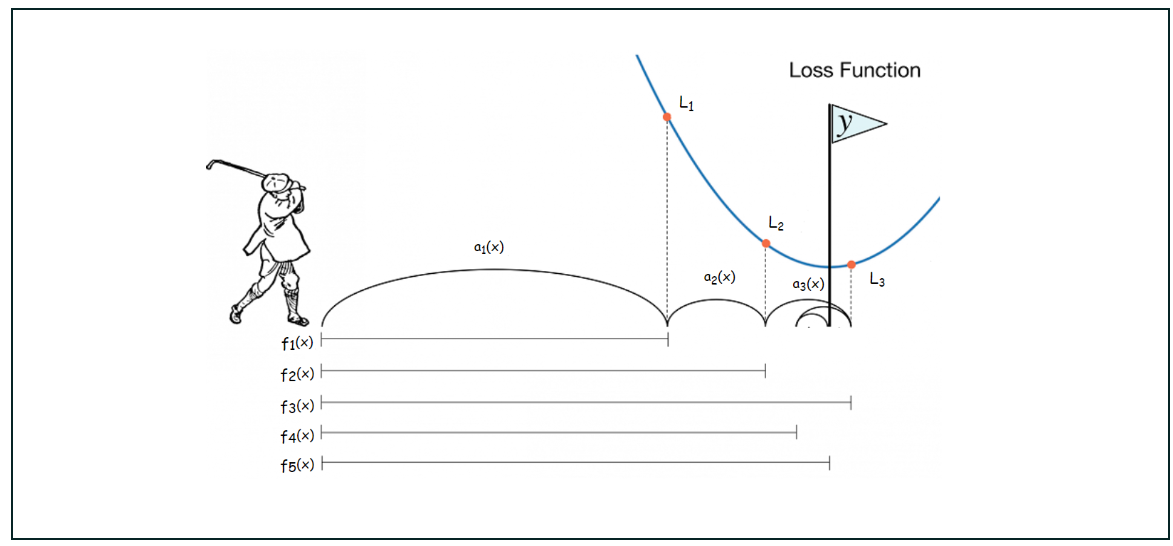

Теперь мы можем перейти к рассмотрению вариаций бустинга и их математической основы.

<center>$\color{green}{\text{AdaBoost}}$</center>

Первый ансамбль типа бустинг, который мы рассмотрим, называется AdaBoost (Adaptive Boosting).

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>Бустинг</b> позволяет из большого количества относительно слабых и простых моделей получить одну сильную. В нашем случае будут рассматриваться деревья решений ограниченной глубины (всего из одного уровня) — их ещё называют пнями.

Для начала давайте вспомним общую логику реализации данного алгоритма, а уже потом сформулируем его математически.

Представим, что у нас есть изначальные данные двух классов: здоровые пациенты (обозначены минусом) и пациенты с диагностированным заболеванием (обозначены плюсом). Мы пытаемся решить задачу классификации. Как можно видеть на графиках ниже, результат первой слабой модели не очень удачный:

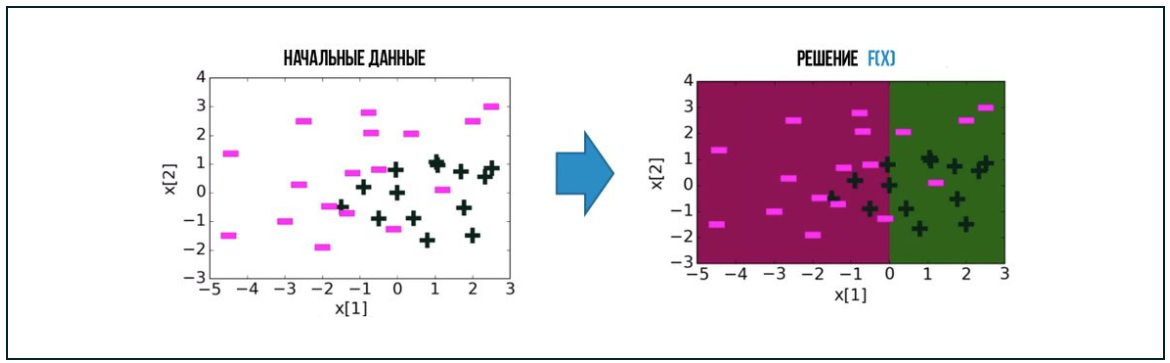

Тогда мы пересчитываем коэффициенты таким образом, чтобы уделить больше всего внимания именно тем наблюдениям, прогнозы для которых были сформированы неверно. На схеме ниже некоторые плюсы и минусы увеличились в размере — это иллюстрирует то, что мы увеличили их веса. После этого мы берём очередную слабую модель и строим новое предсказание (оно справа):

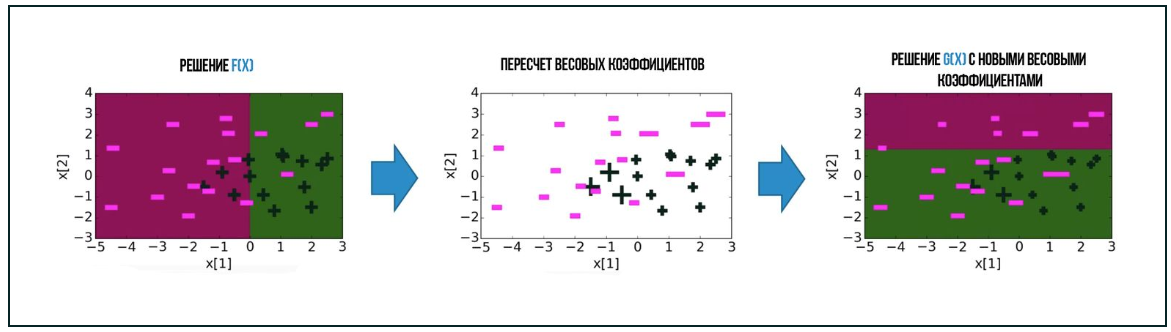

Как видим, результат получился снова не очень хорошим, однако он нивелировал некоторые ошибки, допущенные первым классификатором.  После двух итераций итог следующий:

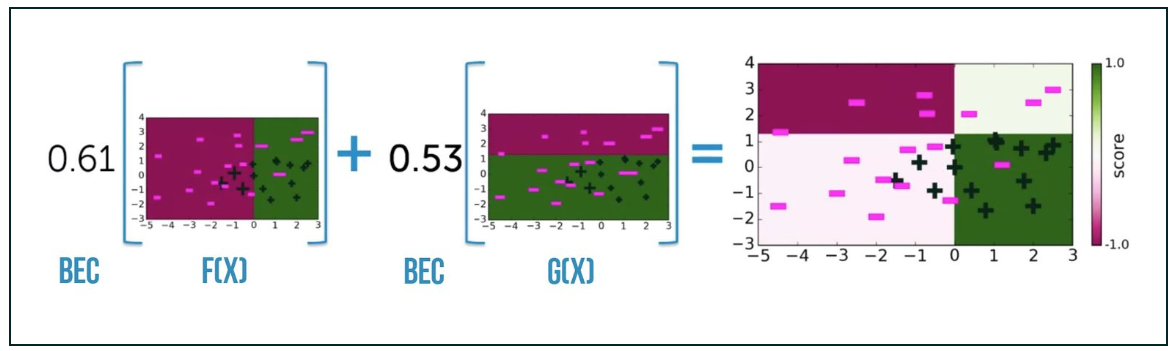

Здесь $f(x)$ и $g(x)$ — результаты применения алгоритмов классификации.

То, что находится в цветной зоне, мы уже с достаточно высокой точностью можем отнести к верному классу. Однако нам необходимо повторять подключение новых моделей, чтобы классифицировать остальные объекты.

Добавляя новые пни, мы в итоге можем добиться достаточно качественного разбиения спустя 30 итераций:

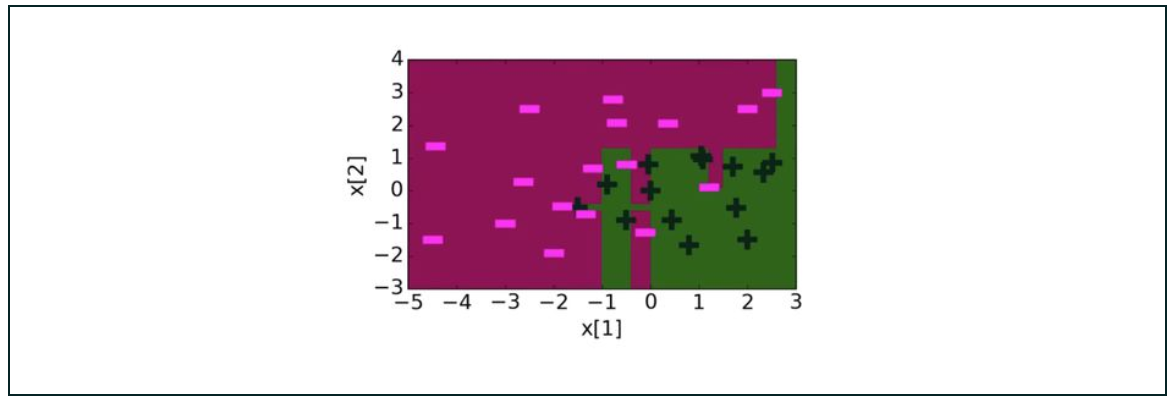

Теперь, когда мы повторили смысл алгоритма AdaBoost, давайте обратимся к его математической составляющей и пропишем сам алгоритм:

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>Инициализируем веса объектов: $$w_{j}=\frac{1}{N}, j=1,2, \ldots, N$$

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span>Для всех $i$ от 1 до K (если у нас K базовых моделей):

2.1. Строим классификатор $a_i(x)$, используя веса $w_i$.

2.2. Вычисляем ошибку: $$\operatorname{err}_{i}=\sum_{j=1}^{N} w_{j}\left[y_{j} \neq a_{i}\left(x_{j}\right)\right]$$

2.3. Вычисляем вес нового алгоритма: $$c_{i}=\frac{1}{2} \ln \frac{1-e r r_{i}}{e r r_{i}}$$

2.4. Получаем новые веса объектов (классы определяются как -1 и +1):$$w_{j} \leftarrow w_{j} \cdot \exp \left(c_{i}\left[y_{j} \neq a_{i}\left(x_{j}\right)\right]\right), j=1, \ldots, N$$

2.5. Нормируем веса объектов:$$w_{j} \longleftarrow \frac{w_{j}}{\sum_{j=1}^{N} w_{j}}$$

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>3</strong></span>Группируем полученные модели: $$f_{K}(x)=\operatorname{sign}\left[\sum_{i=1}^{K} c_{i} a_{i}(x)\right]$$

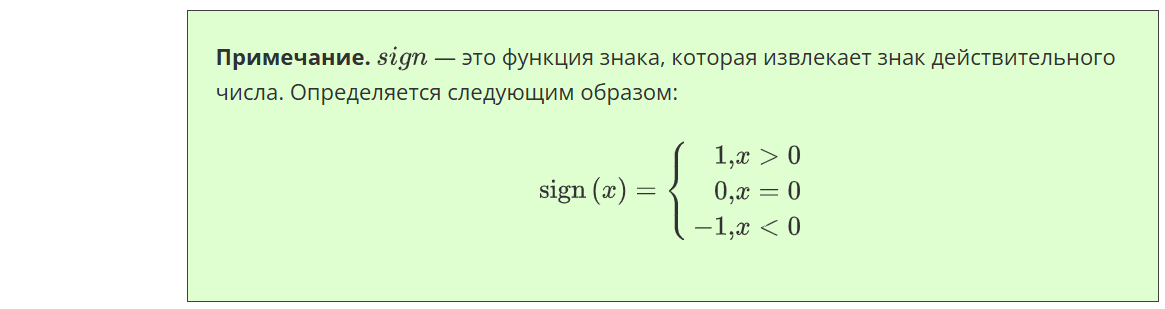

Для лучшего понимания рассмотрим работу алгоритма на «игрушечном» примере ↓

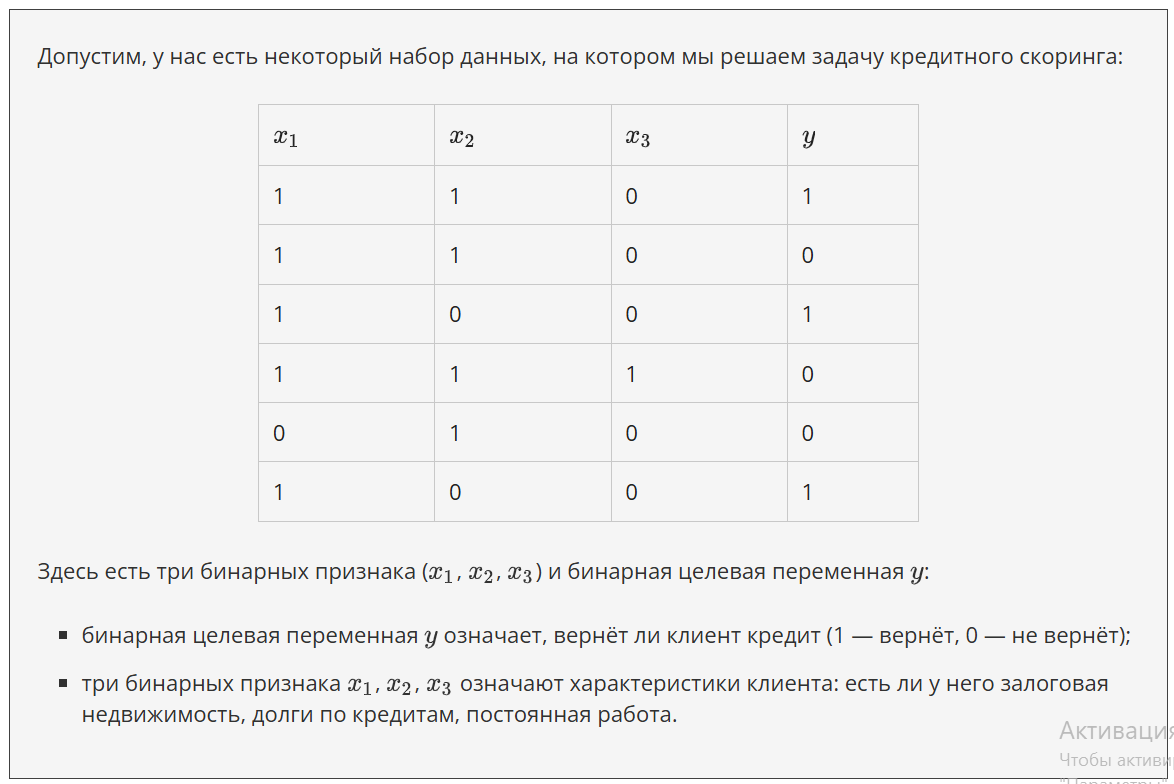

Первоначально все объекты данных будут иметь одинаковый вес $w$: $$w_{j}=\frac{1}{N}, j=1,2, \ldots, N,$$

где $N$ — общее количество объектов.

Можно обобщить всё в одну таблицу:

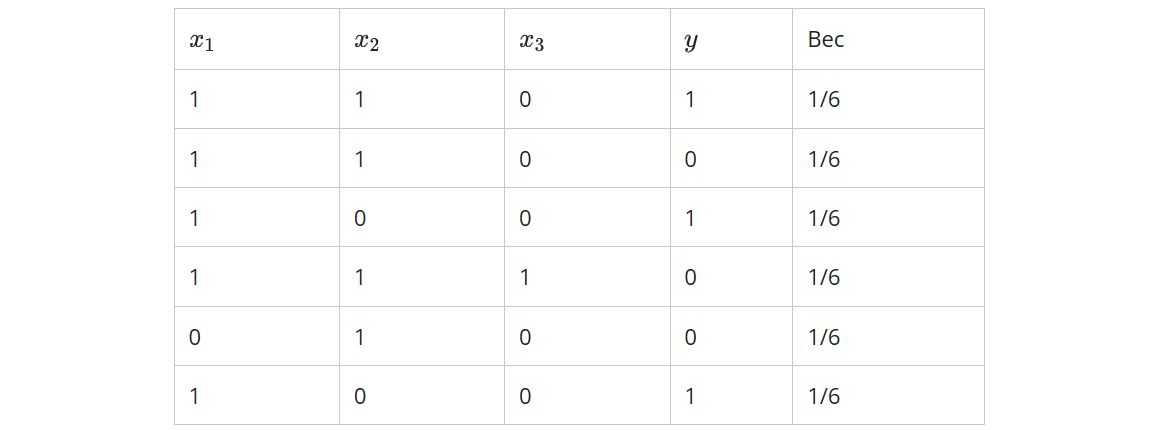

Далее необходимо вычислить, например, значение критерия Джини, чтобы определить, какую переменную использовать для создания первого пня (так как этот коэффициент используется в деревьях решений как критерий качества разбиения). Напомним, что формула критерия Джини выражается следующим образом:

$$H(Q)=\sum_{k=0}^{K} P_{k}\left(1-P_{k}\right),$$

где $Q=\{(x, y)\}$ — обучающая выборка, $P_k$ — вероятность принадлежности к классу $k$, K — количество классов (у нас K=2).

Преобразуем формулу для нашего случая: $$\begin{aligned} & H(Q)=\sum_{k=0}^{K} P_{k}\left(1-P_{k}\right)=P_{0}\left(1-P_{0}\right)+P_{1}\left(1-P_{1}\right) \\=& P_{0}-\left(P_{0}\right)^{2}+P_{1}-\left(P_{1}\right)^{2}=1-\left(P_{0}\right)^{2}-\left(P_{1}\right)^{2} \end{aligned}$$

Здесь:

-  $P_1$ — вероятность принадлежности к классу 1;
-  $P_0$ — вероятность принадлежности к классу  0.

После того как вычислен критерий Джини для каждой вершины, **взвешенная неоднородность вычисляется как средневзвешенное значение**.

Рассмотрим вычисление критерия на примере решающего правила $[x_2 \leq 0.5]$. Так как уникальных значений в признаке $x_2$ всего два — 0 и 1, то это решающее правило будет разделять объекты на две категории: ту, для которой $x_2 =0 $, и ту, для которой $x_1 =1 $.

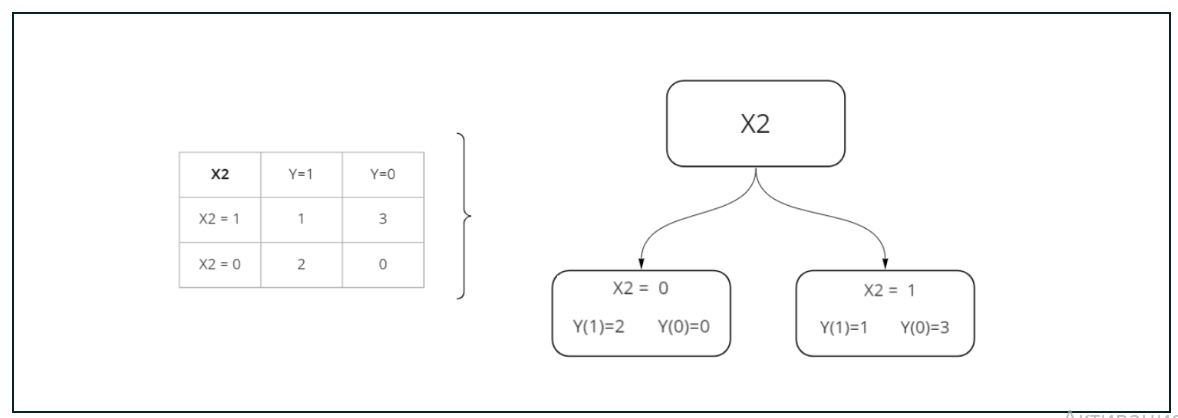

Выше приведена сводная таблица объектов, в которой показано количество наблюдений, попадающих в каждую категорию.

Далее мы можем вычислить критерий Джини каждого значения признака $x_2$:

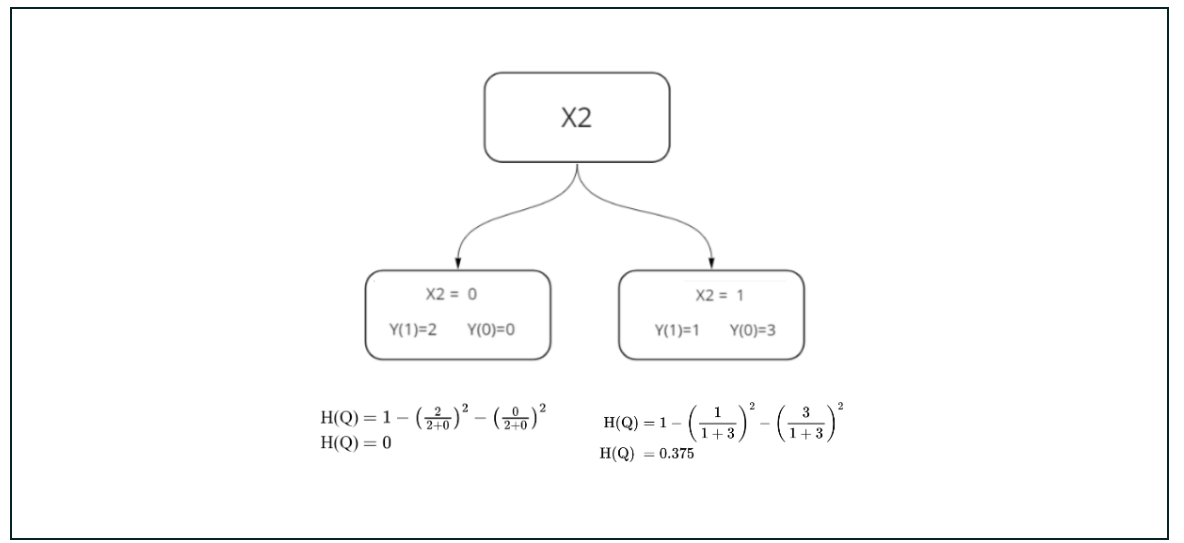

Немного поясним вычисления. Для значения $x_2=1$ один раз встречается единица и три раза — ноль, поэтому общее количество элементарных исходов равняется четырём. Мы можем рассчитать вероятности появления единицы и нуля. Ровно то же самое можно сделать и для $x_2=0$.

После вычисления критерия Джини для каждого значения можно вычислить взвешенную неоднородность, взяв средневзвешенное значение двух критериев:

$$G = 0.375 \left (\frac{4}{4+2}  \right ) + 0 \left (\frac{2}{4+2}  \right )$$

Получаем, что значение взвешенной неоднородности G при разделении по предикату $[x_2 \leq 0.5]$ равно 0.25.

Вы можете проделать тот же путь для каждого признака и в итоге получите, что у признака $x_2$ будет наименьшее значение взвешенной неоднородности. Это значит, именно $x_2$ будет использоваться для создания первого пня.

Далее мы будем использовать общую ошибку, чтобы вычислить вес, который получает этот пень. Общая ошибка равна сумме весов неправильно классифицированных объектов. Тогда получается, что если алгоритм классифицировал первый объект неверно, а остальные — верно, то суммарная ошибка в нашем случае равна 1/6.

Так как мы узнали ошибку, то можем рассчитать вес нового алгоритма:

$$c_{i}=\frac{1}{2} \ln \frac{1-e r r_{i}}{e r r_{i}}$$

В нашем случае:

$$\frac{1}{2} \ln \left(\frac{1-\frac{1}{6}}{\frac{1}{6}}\right)=0.8$$

Далее мы увеличиваем веса объектов, которые были неправильно классифицированы, и уменьшаем веса объектов, которые были классифицированы правильно, используя следующее правило:

$$w_{j} \leftarrow w_{j} \cdot \exp \left(c_{i}\left[y_{j} \neq a_{i}\left(x_{j}\right)\right]\right), j=1, \ldots, N$$

Вычислим новые веса.

Для 1-ого наблюдения:

$$w_{1} \leftarrow \frac{1}{6} \cdot \exp \left(0.8 \cdot \left[1 \neq 0\right]\right) = \frac{1}{6} \cdot \exp (0.8 \cdot 1) = 0.37$$

Для 2-ого наблюдения:

$$w_{2} \leftarrow \frac{1}{6} \cdot \exp \left(0.8 \cdot \left[0 \neq 0\right]\right) = \frac{1}{6} \cdot \exp (0.8 \cdot 0) = 0.17$$

$$w_j \leftarrow \frac{w_j}{\sum_{j=1}^{N} w_j}$$

В результате получаем следующие данные:

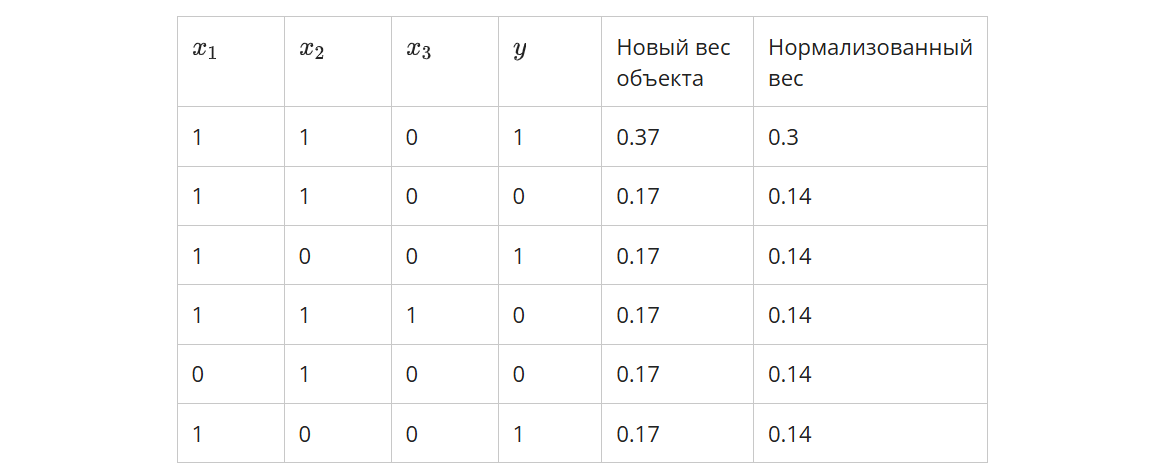

Таким образом, мы смогли рассчитать новые веса выборки. Поскольку сумма весов равняется 1.2, мы нормализовали веса выборки, разделив каждый вес на 1.2, чтобы сумма новых весов выборки равнялась 1.

Теперь мы формируем новую выборку такого же объёма с повтором.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Обратите внимание, что объект, который был классифицирован неправильно, имеет вес, более чем в два раза превышающий вес других объектов. Это означает, что он с большей вероятностью будет выбран несколько раз, и, таким образом, следующий пень будет больше сосредоточен на правильной классификации неправильно классифицированного образца. В этом и состоит идея AdaBoost.

Для того чтобы классифицировать новую точку, мы узнаём предсказание для неё на каждом пне. Затем количество голосов за каждый класс суммируется, и класс с наибольшим количеством голосов становится меткой нашей точки.

<center>$\color{green}{\text{Градиентный бустинг}}$</center>

Переходим к следующему алгоритму, который очень популярен благодаря своей высокой эффективности, — к $\color{green}{\text{градиентному бустингу}}$.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Принцип его работы аналогичен AdaBoost: следующие модели улучшают композицию построенных ранее.

Пусть у нас есть некоторая функция потерь $L(y, \hat{y})$. Она зависит от двух аргументов: y  — истинный ответ, $\hat{y} = a(x)$ — прогноз модели. 

Для задачи регрессии это может быть, например, квадратичная ошибка

$$L(y, \hat{y})=(y-\hat{y})^{2},$$

а для задачи классификации — логистическая функция потерь (классы определяются как 0 и 1):

$$LogLoss = -\frac{1}{N}\sum^N_{i=1} ( y_i \cdot\log{p(y_i)} + (1 - y_i) \cdot\log{(1 - p(y_i))}),$$

где N — количество элементов в выборке, $y_i$ — метка класса, а $p(y_i)$ — предсказанная вероятность этого класса.

Пусть к некоторому моменту обучены K-1 алгоритмов $a_1 (x), ..., a_{K-1}(x)$, то есть композиция имеет вид:

$$f_{K-1}(x)=\sum_{i=1}^{K-1} a_{i}(x)$$

Теперь добавляем в композицию ещё один алгоритм — $a_K (x)$. Этот алгоритм обучается так, чтобы как можно сильнее уменьшить ошибку композиции на обучающей выборке:

$$\sum_{j=1}^{N} L\left(y_{j}, f_{K-1}\left(x_{j}\right)+a_k\left(x_{j}\right)\right) \rightarrow \min _{a_k}$$

Для того чтобы найти , минимизирующее функционал, задачу разбивают на **две подзадачи**:

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>
На первом этапе определяем, какие значения $s_1, ..., s_N$ должен принимать алгоритм $a_K (x_j) = s_j$, чтобы на объектах обучающей выборки ошибка была минимальной. Формально это можно представить так:

$$F(s)=\sum_{j=1}^{N} L\left(y_{j}, a_{K-1}\left(x_{j}\right)+s_{j}\right) \rightarrow \min _{s},$$

где $s = (s_1, ..., s_n)$.

Иными словами, необходимо найти такой вектор сдвигов s, который будет минимизировать функцию $F(s)$.

Вы, вероятно, помните, что направление наискорейшего убывания функции — это антиградиент, так что берём его в качестве вектора s: $$s=-\nabla F=\left[\begin{array}{c}-L_{\hat{y}}^{\prime}\left(y_{1}, a_{K-1}\left(x_{1}\right)\right) \\ -L_{\hat{y}}^{\prime}\left(y_{2}, a_{K-1}\left(x_{2}\right)\right) \\ \vdots \\ -L_{\hat{y}}^{\prime}\left(y_{N}, a_{K-1}\left(x_{N}\right)\right)\end{array}\right]$$

Компоненты данного вектора — это те значения, которые должен принимать алгоритм $a_K (x)$ на объектах обучающей выборки, чтобы итоговая ошибка композиции была как можно меньше

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span>Второй этап — построение такого алгоритма $a_K (x)$. По сути, задача построения алгоритма $a_K (x)$ — это обычная задача регрессии на размеченных данных. В данном случае у нас есть обучающая выборка $(x_j, s_j)^N_{j=1}$ — нам просто нужно предсказать значения вектора s. Например, используем квадратичную функцию потерь: $$a_{K}(x)=\arg \min _{a} \frac{1}{N} \sum_{j=1}^{N}\left(a\left(x_{j}\right)-s_{j}\right)^{2}$$

Запишем **последовательность шагов реализации алгоритма**, которую можно запрограммировать:

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>
Инициализируем композицию <b>GBM (Gradient Boosting Machine)</b> — $f(x) = a_0 (x)$, то есть добавляем первый базовый алгоритм. Например, можно использовать:

- алгоритм $a_0 (x) = 0$, который всегда возвращает 0 (в задаче регрессии);
- более сложный алгоритм $a_0 (x) = \frac{1}{N} \sum_{j=1}^N y_i$, который возвращает средний истинный ответ по всем элементам обучающей выборки (в задаче регрессии);
- алгоритм $a_0 (x) = arg \ max_{y \in Y} \sum_{j=1}^N \left [y_i = y  \right ]$, который всегда возвращает метку самого распространённого класса в обучающей выборке (в задаче классификации).

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span>
Итеративно повторяем следующие три шага:

2.1. Вычисляем вектор сдвига: $$s=-\nabla F=\left[\begin{array}{c}-L_{\hat{y}}^{\prime}\left(y_{1}, a_{K-1}\left(x_{1}\right)\right) \\ -L_{\hat{y}}^{\prime}\left(y_{2}, a_{K-1}\left(x_{2}\right)\right) \\ \vdots \\ -L_{\hat{y}}^{\prime}\left(y_{N}, a_{K-1}\left(x_{N}\right)\right)\end{array}\right]$$

2.2. Строим очередной базовый алгоритм $a_K (x)$, который предсказывает вектор-сдвиг:$$a_{K}(x)=\arg \min _{a} \frac{1}{N} \sum_{j=1}^{N}\left(a\left(x_{j}\right)-s_{j}\right)^{2}$$

2.3. Добавляем $a_K (x)$ в композицию:$$a_{K}(x)=\sum_{i=1}^{K} a_{i}(x)$$

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>3</strong></span>
Если выполнен критерий остановки, останавливаем итеративный процесс.

Давайте рассмотрим алгоритм на простейшем примере, чтобы лучше усвоить все шаги ↓

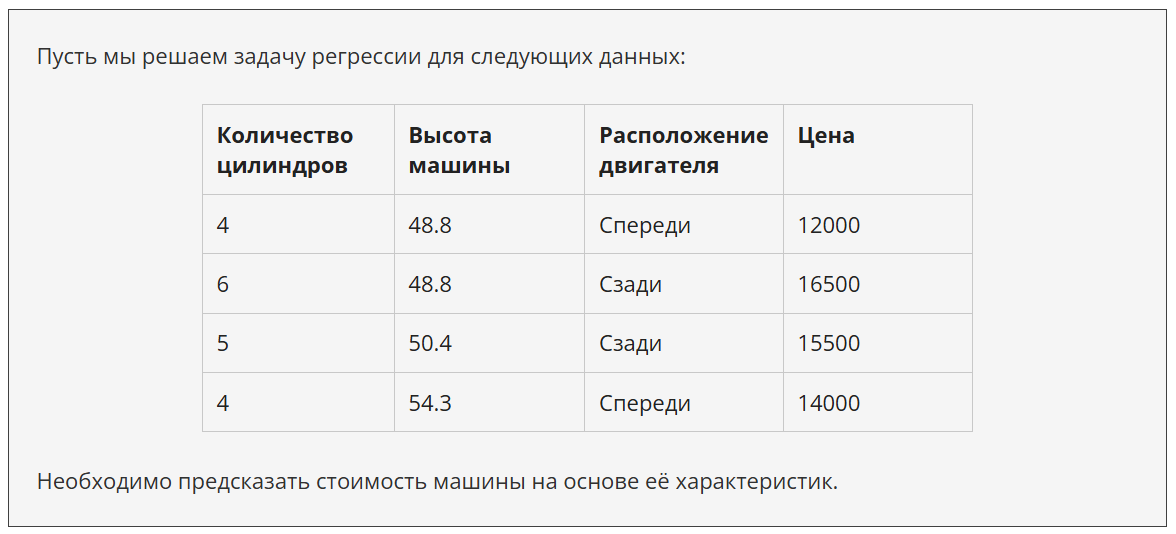

Будем решать данную задачу с помощью градиентного бустинга над решающими деревьями.

Для начала, в соответствии с описанным выше алгоритмом, нам необходимо инициализировать GBM базовым алгоритмом. Сделаем это с помощью среднего значения целевой переменной

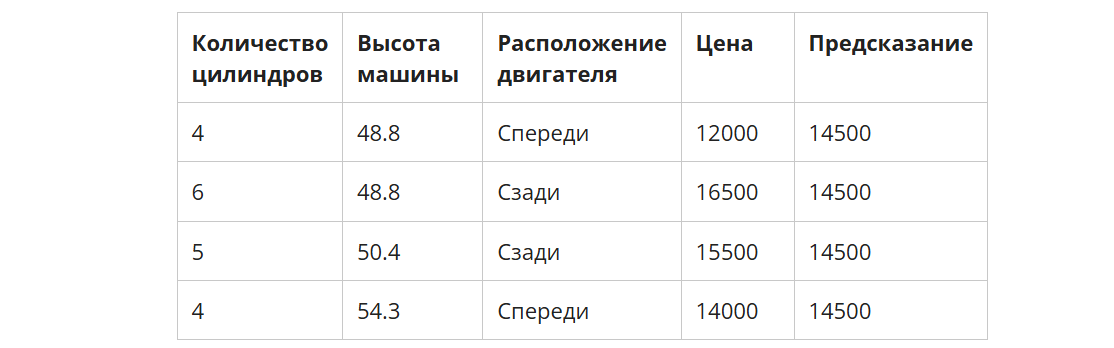

Почему именно с помощью среднего значения, а не другого константного? Дело в том, что именно в среднем будет минимальное значение функции потерь. Давайте это докажем.

Так как мы решаем задачу регрессии, то возьмём классическую для этого случая метрику MSE:

$$L(y, \ \hat{y})=\frac{1}{N} \sum_{i=1}^{N}\left(y_{i}-\hat{y}_{i}\right)^{2}$$

Чтобы найти минимум, необходимо найти производную — вам это уже известно из модулей по математическому анализу. Производная:

$$\frac{dL(y, \ \hat{y})} {d \hat{y}}=\frac{-2}{N} \sum_{i=1}^{N}\left(y_{i}-\hat{y}_{i}\right)$$

Мы видим, что здесь антиградиентом является разница между реальным значением функции и предсказываемым — обычно эту разницу называют **псевдоостатками**.

Если мы подставим значения из нашего примера, результат будет следующим:

$$L(y, \ \hat{y})=\frac{1}{4}(12000-\hat{y})^{2}+\frac{1}{4}(16500-\hat{y})^{2}+\frac{1}{4}(15500-\hat{y})^{2} +\frac{1}{4}(14000-\hat{y})^{2}$$

$$\frac{dL(y, \ \hat{y})} {d \hat{y}}=-\frac{2}{4}(12000-\hat{y})-\frac{2}{4}(16500-\hat{y})-\frac{2}{4}(15500-\hat{y})-\frac{2}{4}(14000-\hat{y})$$

Приравниваем производную к нулю:

$$\frac{dL(y, \ \hat{y})} {d \hat{y}}=0$$

$$-\frac{2}{4}(12000-\hat{y})-\frac{2}{4}(16500-\hat{y})-\frac{2}{4}(15500-\hat{y})-\frac{2}{4}(14000-\hat{y})=0$$

$$(12000-\hat{y})+(16500-\hat{y})+(15500-\hat{y})+(14000-\hat{y})=0$$

$$58000-4 \hat{y}=0$$

$$\hat{y}=\frac{58000}{4}=14500$$

Собственно, мы получили как раз среднее арифметическое.

Далее вычисляем **псевдоостатки**:

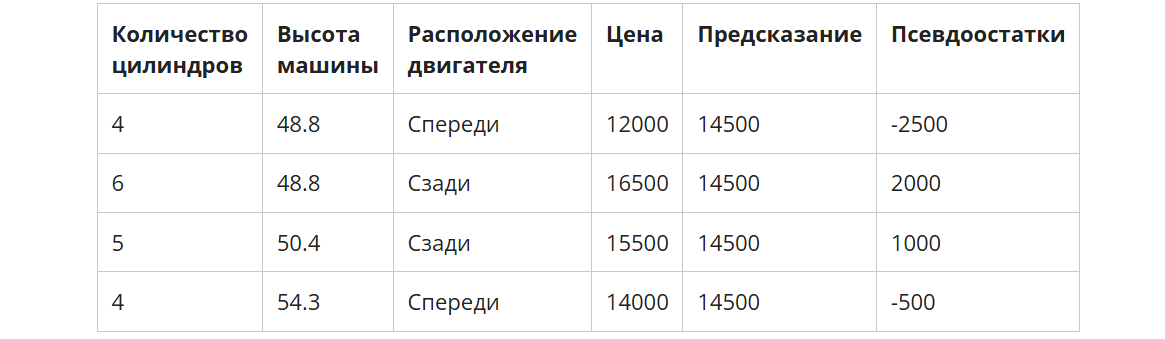

а следующем шаге мы строим регрессионную модель, которая будет предсказывать псевдоостатки.

Находим значения для всех листьев нашего дерева решений. Предположим, дерево получилось таким:

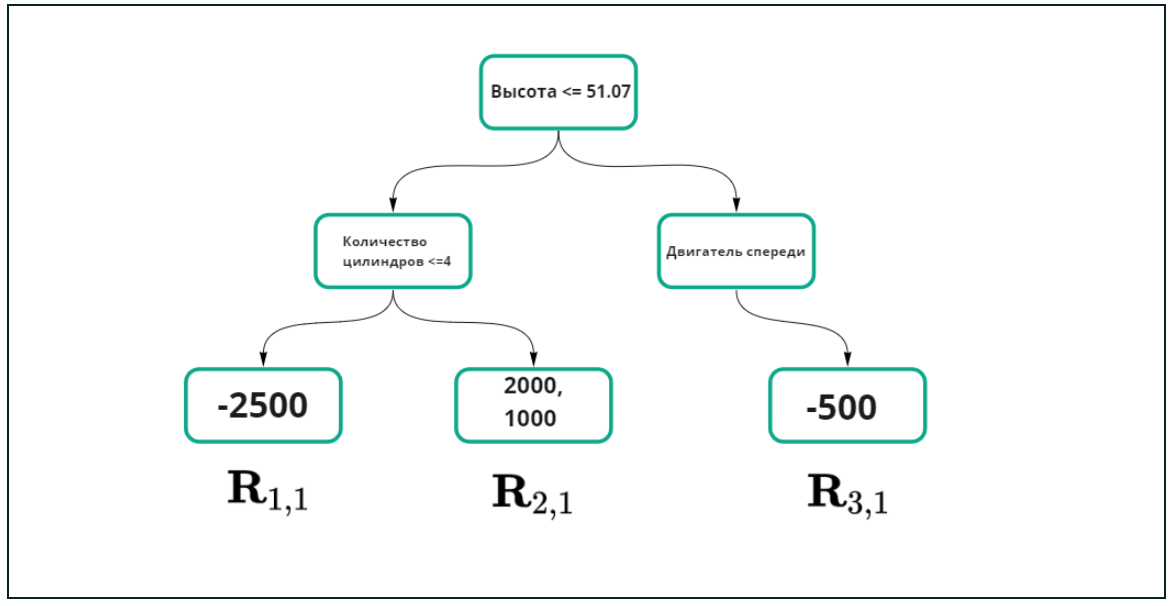

Нужно оставить в каждом листе по одному значению, которое будет минимизировать функцию: это либо сам остаток, либо среднее арифметическое чисел, если в листе их несколько.

Мы берём именно эти значения, так как нам необходимо минимизировать разницу между реальной ценой и предсказанием. В алгоритме градиентного бустинга выше мы прописывали, что таким образом мы будем строить очередной базовый алгоритм, предсказывающий вектор-сдвиг:

$$\hat{y}_{1,1}=\operatorname{argmin} (12000-(14500+\hat{y}))^{2}$$

$$\hat{y}_{1,1}=\operatorname{argmin} (-2500-\hat{y})^{2}$$

Скорее всего, из модуля по математическому анализу вы помните, что для того, чтобы найти точку минимума функции, необходимо приравнять значение производной к нулю:

$$\frac{d}{d \hat{y}}(-2500-\hat{y})^{2}=0$$

$$-2500-\hat{y}=0$$

$$\hat{y}=-2500$$

Для второго листа:

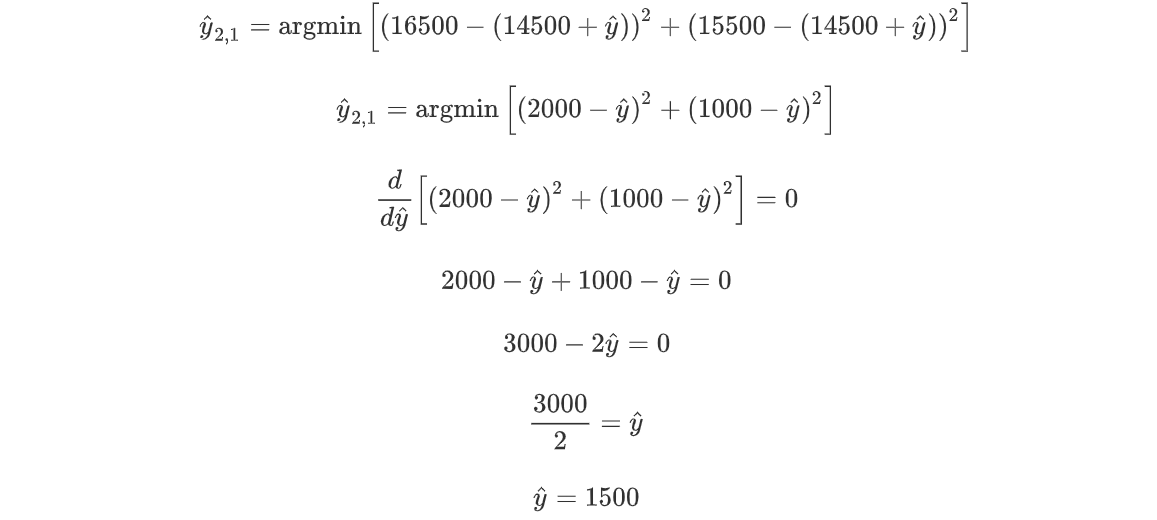

Для третьего листа:

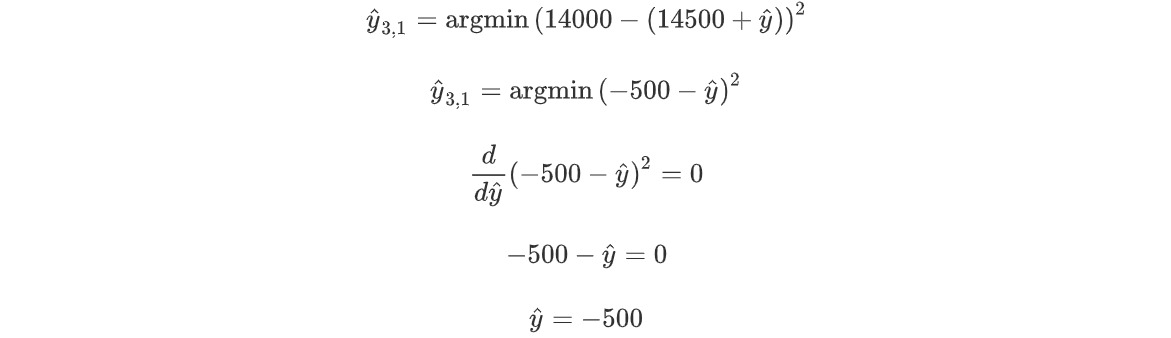

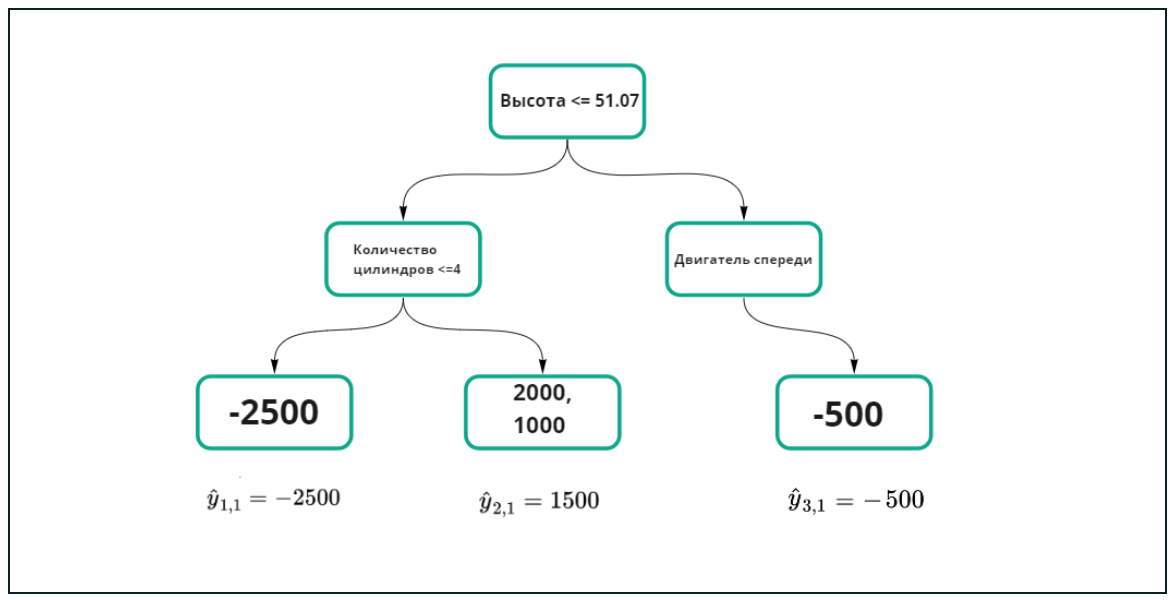

Теперь, наконец, обновляем нашу модель:

$$f_{K+1}(x)=f_{K}(x)+\eta a(x)$$

За $\eta$ здесь обозначен темп обучения.

По сути, у нас получился уже известный вам алгоритм градиентного спуска, который реализован в пространстве ответов ансамбля.

Схематично это можно изобразить так:

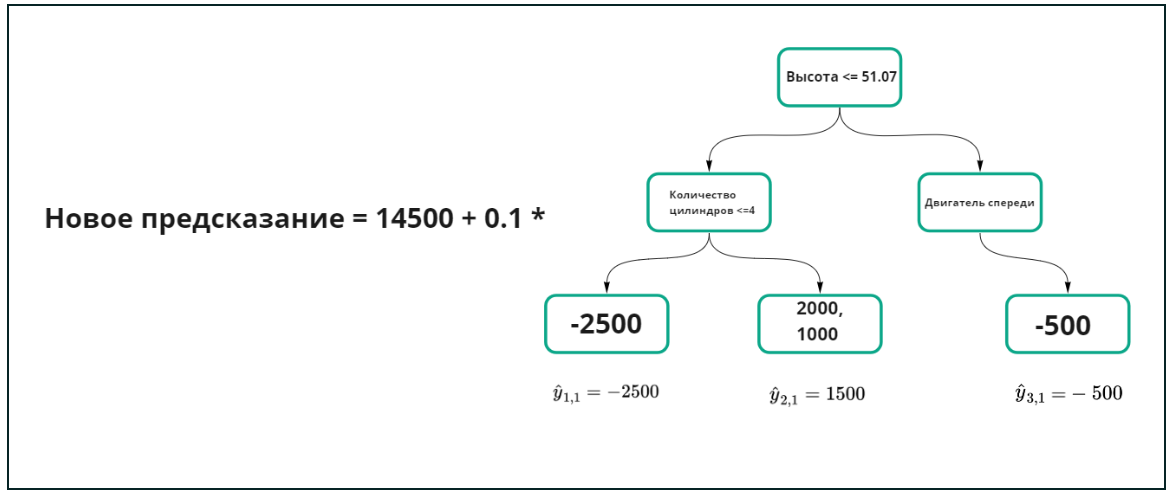

Но прежде чем закончить с этим примером, давайте сделаем предсказание хотя бы на такой простой модели. Пусть у нас есть автомобиль, высота которого — 49 и у которого 6 цилиндров. В таком случае мы получаем подходящее для нас значение $\hat{y}_{2,1} = 1500$ и вычисляем предсказание цены:

$$Цена = 14500 + 0.1*1500 = 14500 + 150 = 14650$$

Но, конечно, это лишь промежуточный результат. В реальности, чтобы прогноз был как можно точнее, должно было бы быть построено ещё много деревьев.

Напомним изученные ранее плюсы и минусы бустинга:

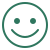
- модели обучаются последовательно, уточняя друг друга;
- снижается смещение;
- базовые модели — неглубокие деревья.

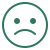

- вычисление плохо параллелится;
- плохо интерпретируемые результаты.

<center>$\color{green}{\text{XGBoost и CatBoost}}$</center>

Теперь, когда мы разобрались с градиентным бустингом, необходимо также упомянуть о двух его популярных на данный момент вариациях — **XGBoost** и **CatBoost**.

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>XGBoost</b> — одна из самых эффективных реализаций алгоритма Gradient Boosted Trees. Название XGBoost расшифровывается  как eXtreme Gradient Boosting. XGBoost — это улучшение GBM через системную оптимизацию и усовершенствование алгоритма.

У XGBoost есть ряд существенных улучшений по сравнению с классической реализацией градиентного бустинга:

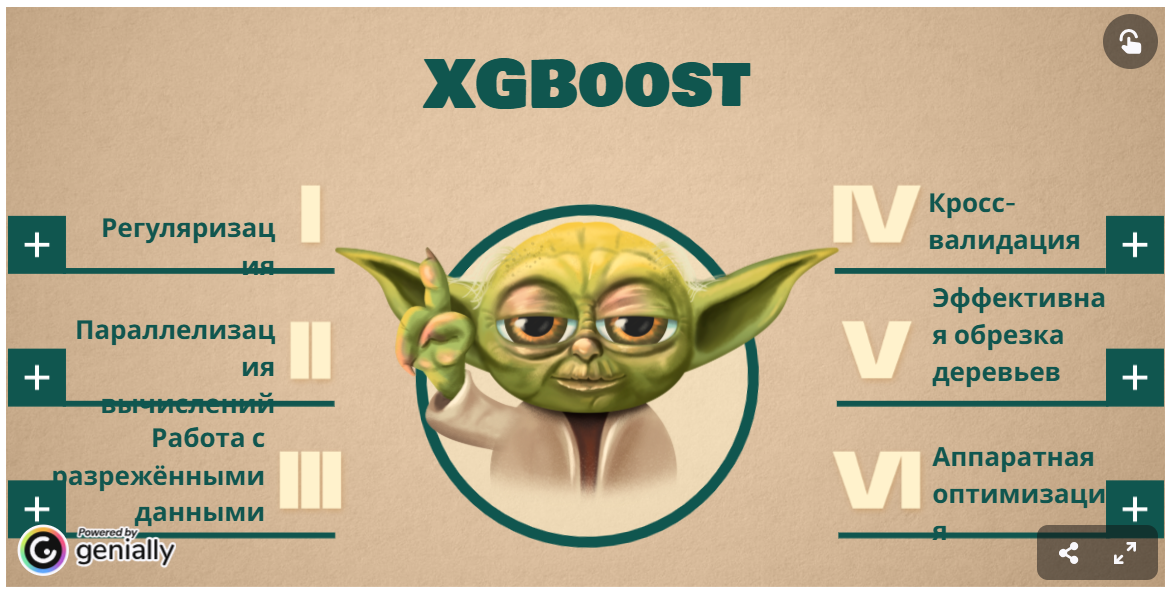

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>CatBoost</b> — это библиотека градиентного бустинга, созданная Яндексом. Её особенность заключается в том, что в ней используются так называемые <b>небрежные (oblivious) деревья решений</b>, чтобы «вырастить» сбалансированное дерево.

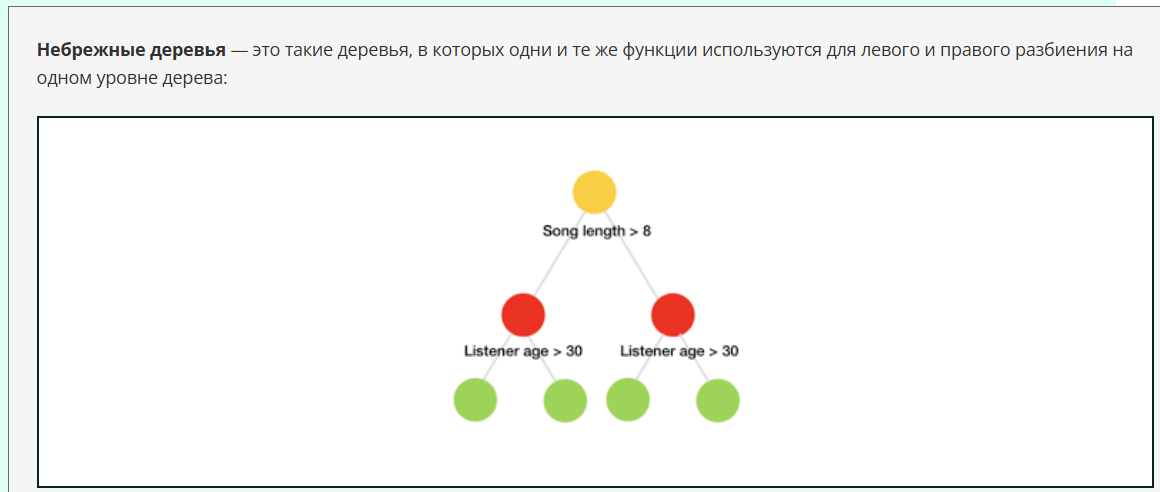

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Одно из <b>главных преимуществ CatBoost</b> заключается в том, что его можно использовать для данных, где категориальные признаки заранее не были преобразованы.

Подробнее узнать о CatBoost можно в [видеопрезентации Яндекса](https://youtu.be/UYDwhuyWYSo).

Итак, мы разобрались с очень важным видом ансамблей — бустингом и рассмотрели несколько его моделей:

- **[AdaBoost](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)** — самый простой вариант бустинга;
- **[GBM](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)** — классический градиентный бустинг;
- **[XGBoost](https://xgboost.readthedocs.io/en/stable/)** — улучшенная версия градиентного бустинга;
- **[CatBoost](https://catboost.ai/)** — улучшенная версия градиентного бустинга, адаптированная для работы с категориальными переменными.

##  6. Бустинг. Практика

#### См. MATH&ML/MATH&ML. Практика оцениваемая ментором/MATH&ML-9 Бустинг. Практика

 ## 7. Стекинг

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>Стекинг</b> —  это агрегация ответов моделей машинного обучения. Подход использует понятие <b>базовых моделей</b>, каждая из которых обучается независимо от остальных, и <b>метамодели</b>, которая использует предсказания базовых моделей как признаки.

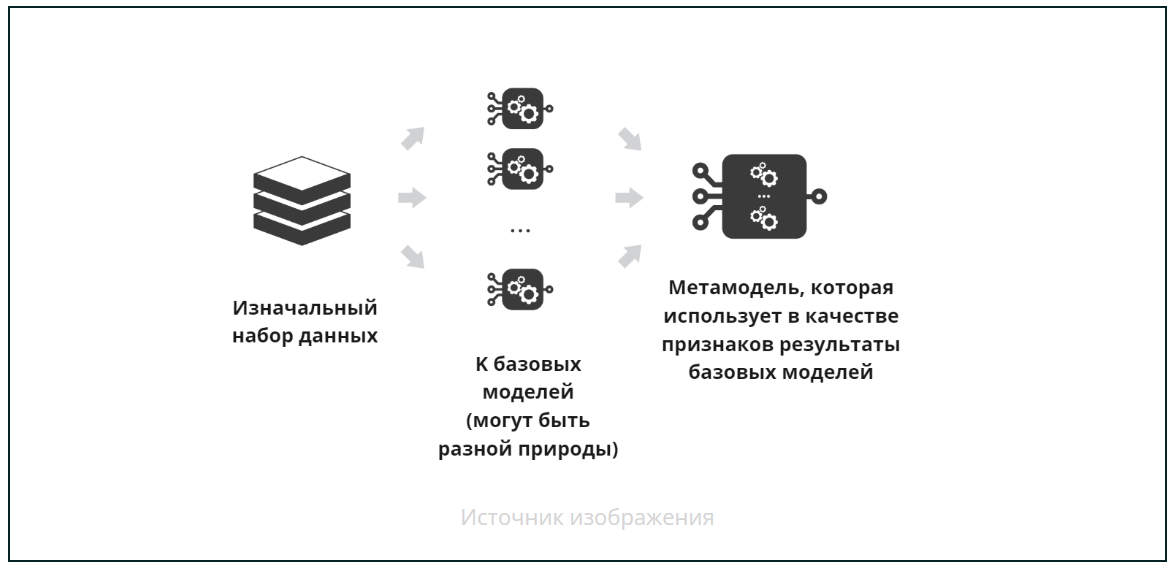

Представим, что мы обучили $K$ базовых моделей $a_1 (x), ..., a_K (x)$ на некоторой выборке и теперь хотим использовать их результаты для обучения метамодели $f(x)$.

Самый простой вариант — обучить метамодель на той же выборке. Тогда функция потерь будет выражаться следующим образом:

$$\sum_{i=1}^{N} L\left(y_{i}, f\left(a_{1}\left(x_{i}\right), \ldots, a_{K}\left(x_{i}\right)\right)\right) \rightarrow \min _{f}$$

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">→ В таком случае метамодель $f$ будет отдавать предпочтение тем базовым алгоритмам, которые сильнее других подстроились под целевую переменную при обучении, так как по их прогнозам проще всего предсказывать правильные ответы. Если среди базовых алгоритмов будет тот, который просто запомнил все ответы на обучающей выборке, то метаалгоритму будет проще всего использовать только прогнозы данного переобученного базового алгоритма, ведь такой подход будет давать максимальный результат. Но, разумеется, высокое качество в таком случае будет только на обучающей выборке — на тестовой оно будет значительно хуже.

Поэтому важно отметить, что **базовые алгоритмы и метамодель должны обучаться на разных выборках**. 

Разобьём выборку на $L$ частей: $X_1, X_2, ..., X_L$. Пусть $a^{-l}_j (x)$ — это базовый $j$-й алгоритм, который обучен на всех подвыборках, кроме выборки под номером $l$.

Как мы уже выяснили, чтобы избежать переобучения, необходимо обучать базовые модели и метамодель на разных выборках. Это можно делать с помощью $\color{green}{\text{блендинга}}$ или $\color{green}{\text{стекинга}}$.

<center>$\color{green}{\text{Блендинг}}$</center>

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>Блендинг</b> является простейшей реализацией стекинга.

Предположим, у нас есть обучающая выборка $X$, которую мы делим пополам: первая часть используется для обучения базовых моделей, а на второй базовые модели делают предсказания — метапризнаки, на которых и обучается в дальнейшем метамодель.

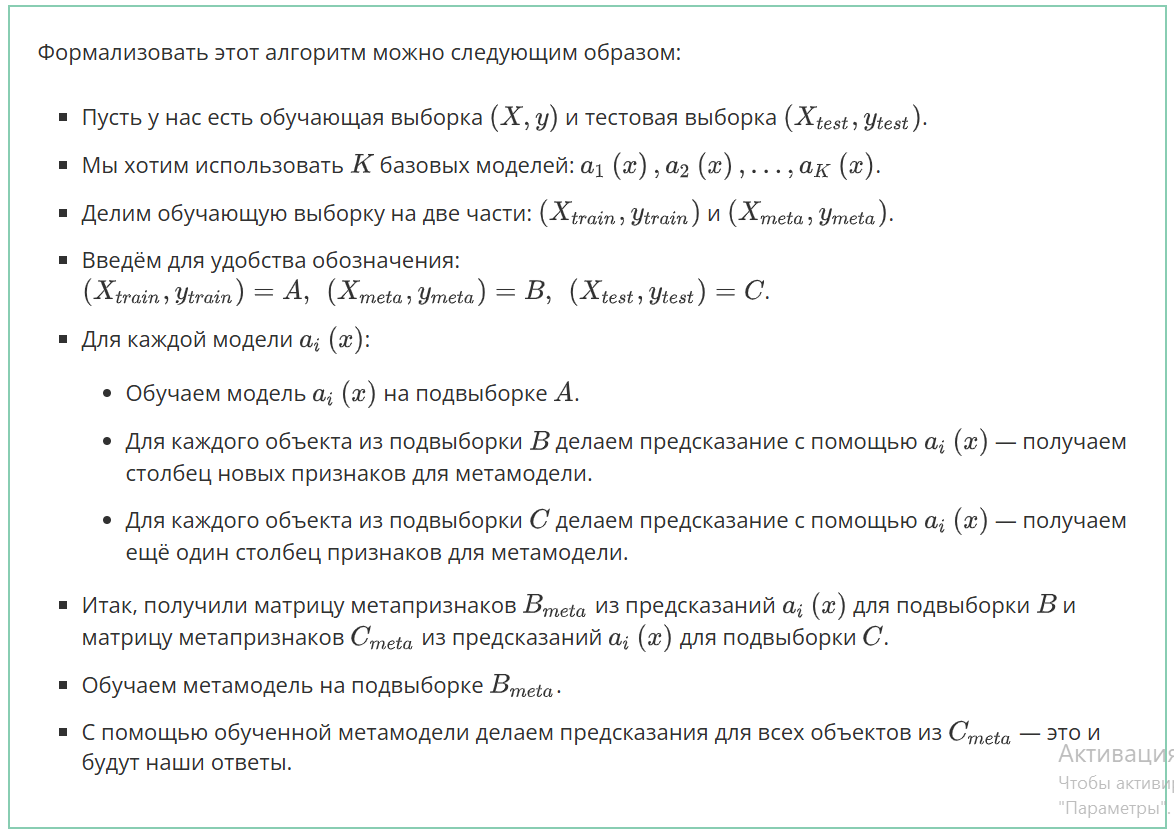

Важно отметить, что для блендинга можно и нужно использовать базовые алгоритмы разной природы: например, вы можете объединять KNN, метод опорных векторов, решающие деревья и на результатах этих базовых алгоритмов обучать метамодель.

Метамодель тоже может быть разной природы, но часто в качестве неё берут просто линейную модель:

$$f(x) = \sum^K_{i = 1} w_i a_i (x)$$

Схематично описанный выше алгоритм можно изобразить следующим образом:

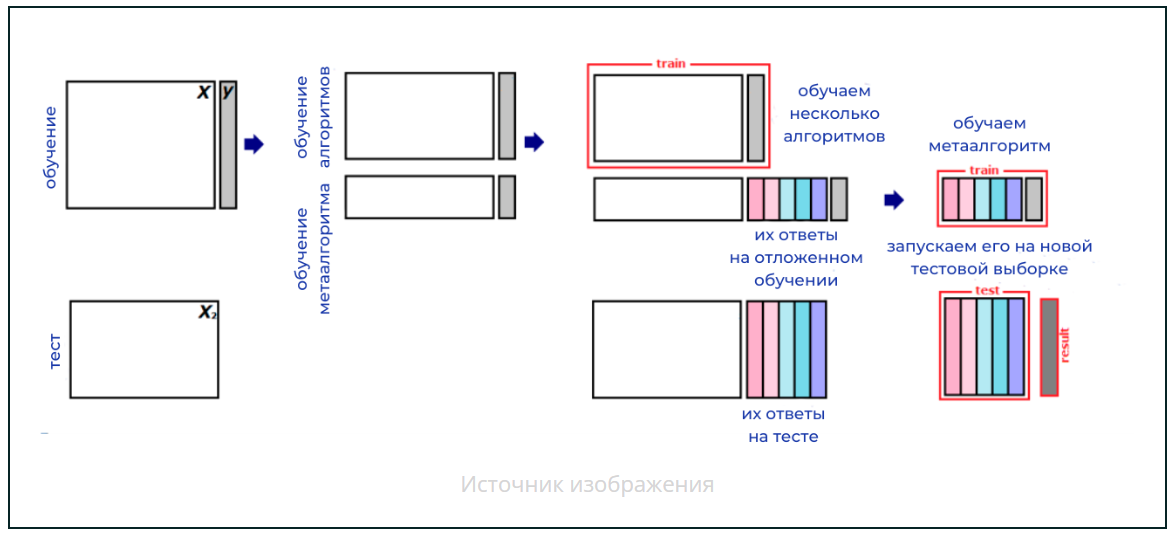

<center>$\color{green}{\text{Стекинг}}$</center>

 <p style="background: #ffc7c7; border:1px black  solid; text-align: left; padding: 10px">К сожалению, у блендинга есть проблема: ни базовые модели, ни метамодель не обучаются на полных данных.

Эту проблему решает **стекинг**.

Чтобы в итоге все модели могли «познакомиться» с полным набором данных, можно использовать подход, аналогичный кросс-валидации: мы можем разделять выборку на $L$ частей, обучать модель на части $L-1$ и делать предсказание на оставшейся. Определённого правила для выбора количества частей нет, но, разумеется, чем больше их будет, тем выше будет качество (времени на обучение также будет потрачено больше).

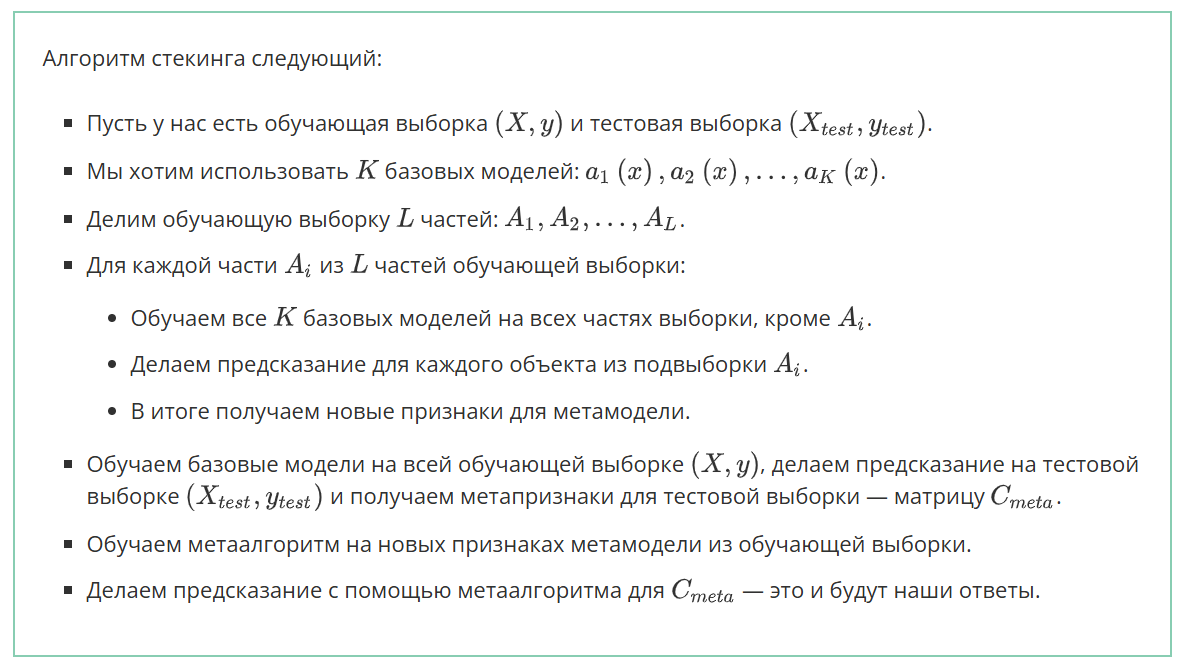

Схематично можно изобразить это так:

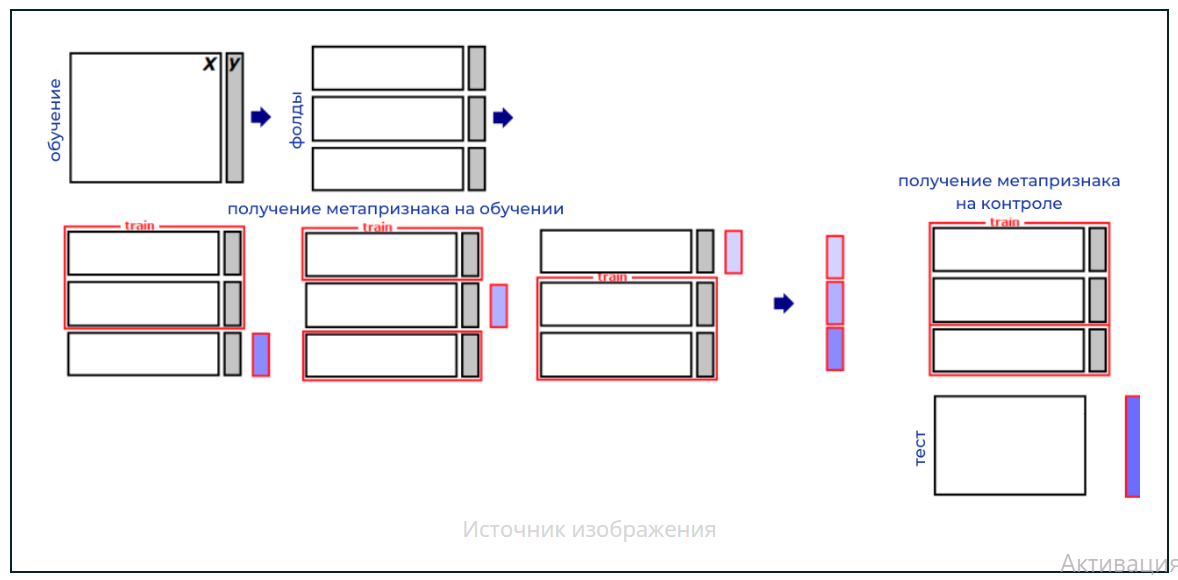

Несомненный **плюс стекинга** в том, что использование различных видов алгоритмов может помочь идентифицировать сложные зависимости. Например, ниже можно видеть иллюстрацию задачи классификации, где структура данных довольно сложная, но при использовании нескольких алгоритмов получается её выявить.

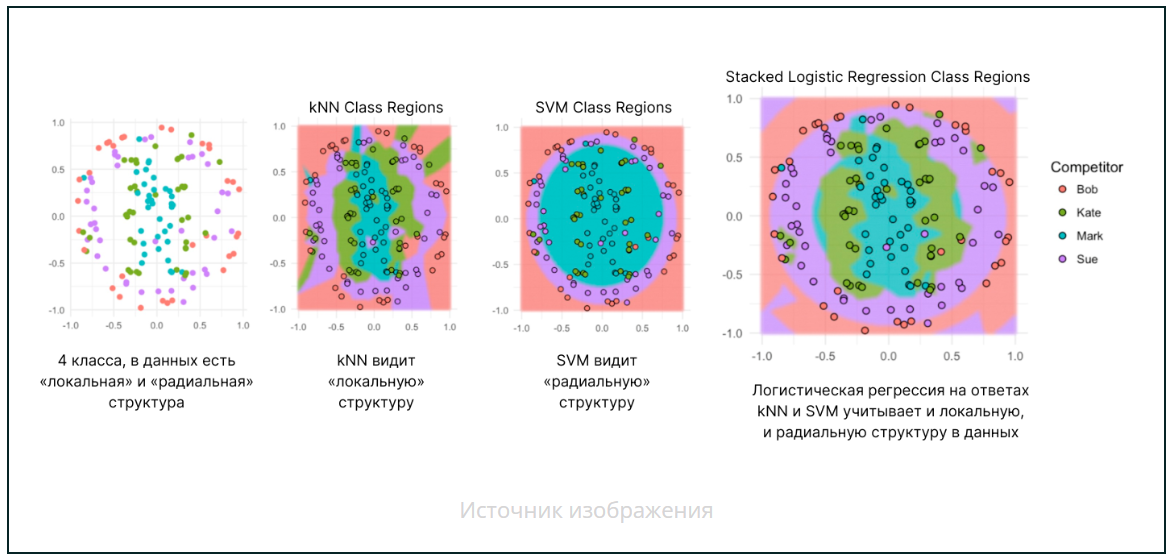

Также метод стекинга можно реализовать с более чем двумя уровнями — это называется **многоуровневым стекингом**. В таком случае мы определяем базовые модели, затем обучаем ряд метамоделей на результатах базовых моделей и в итоге обучаем конечную метамодель. Рассматривать и реализовывать такой подход мы не будем, так как улучшение качества будет незначительным, а вычислительные затраты — невероятно высокими.

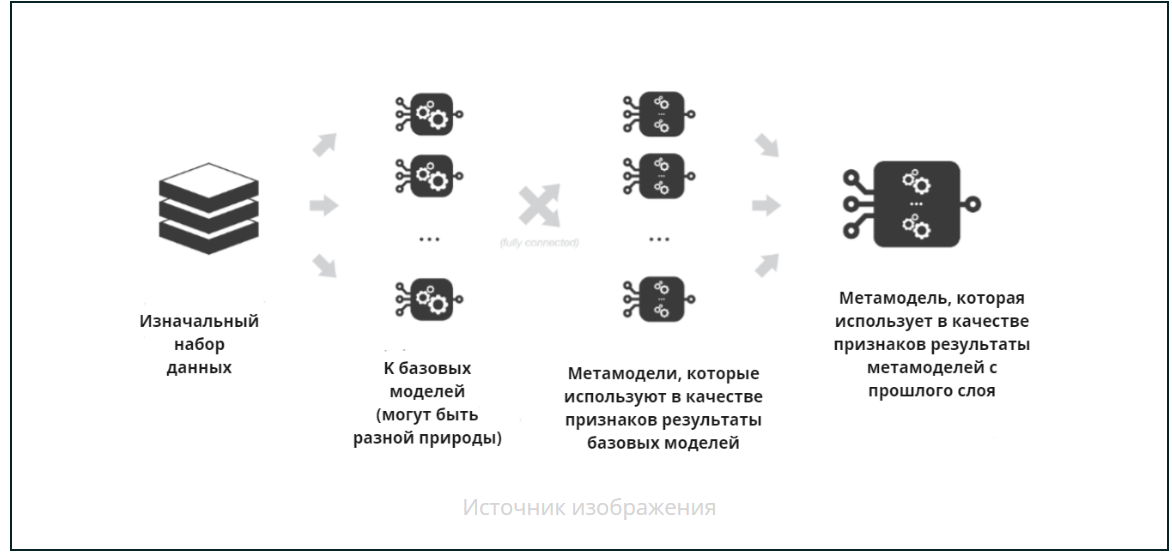

Возможно, вы заметили, что принцип многоуровневого стекинга очень похож на принцип работы искусственных нейронных сетей, о которых мы говорили ранее в модуле про оптимизацию, и это действительно так.

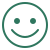

- хорошо параллелится (модели обучаются параллельно);
- хорошо подходит для использования различных по природе базовых моделей

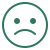

- качество сильно зависит от качества базовых моделей;
- плохо интерпретируемые результаты

#### См. MATH&ML/MATH&ML. Практика оцениваемая ментором/MATH&ML-9 Стекинг. Практика

<p style="border:3px black solid; text-align: left; padding: 10px">Отлично, мы увидели, как сильно улучшает качество применение стекинга. Несмотря на недостатки этого метода (долгое обучение, необходимость подбора параметров, редкое использование на практике — зачастую лишь для того, чтобы добыть дополнительные баллы на Kaggle), в определённых ситуациях он может быть очень полезен. Если у вас достаточно вычислительных ресурсов, вы готовы потратить время на подбор моделей и параметров, а точность модели крайне важна, стекинг сослужит вам хорошую службу.

<p style="border:3px black solid; text-align: left; padding: 10px">✍ В этом модуле мы рассмотрели ансамблевые методы машинного обучения. Мы не только повторили основные концепции, но и разобрались с математическими основами алгоритмов.

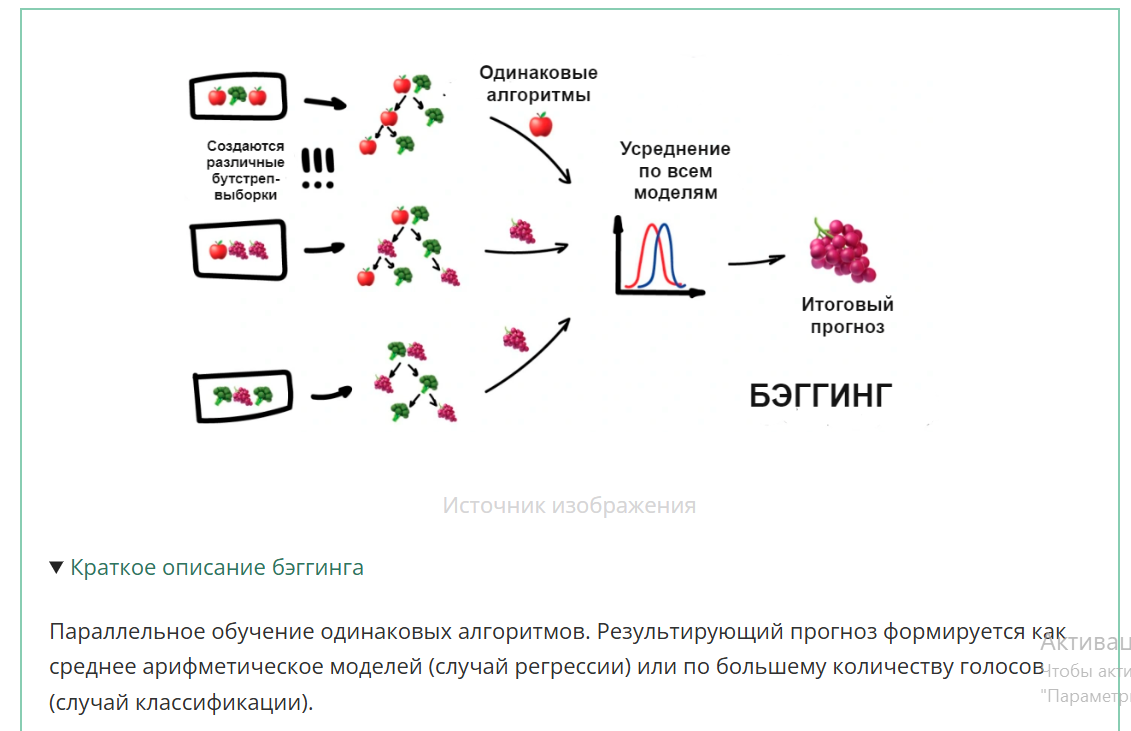

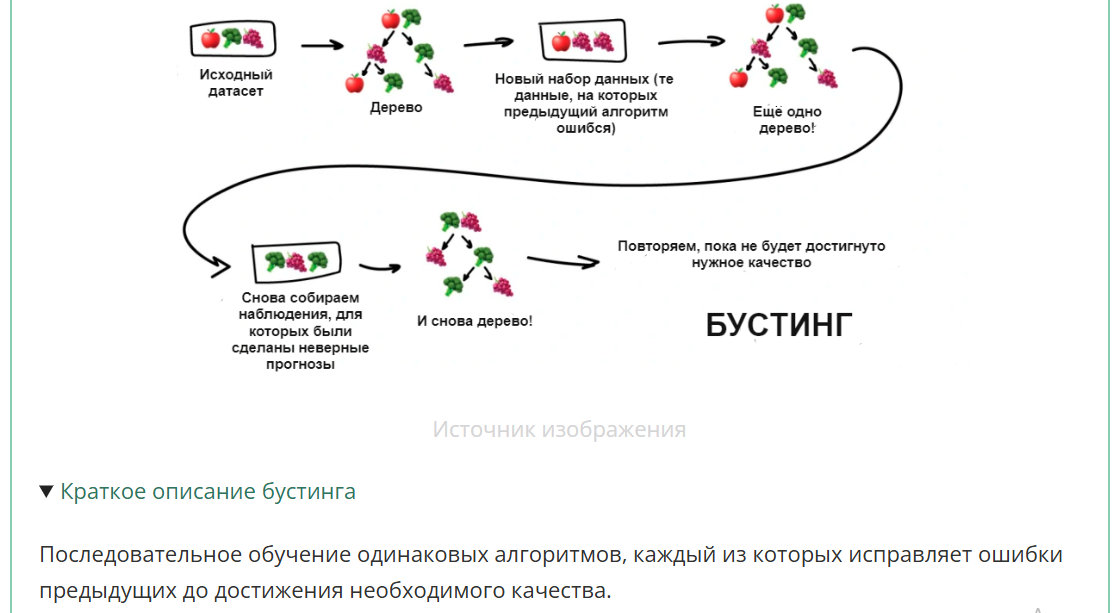

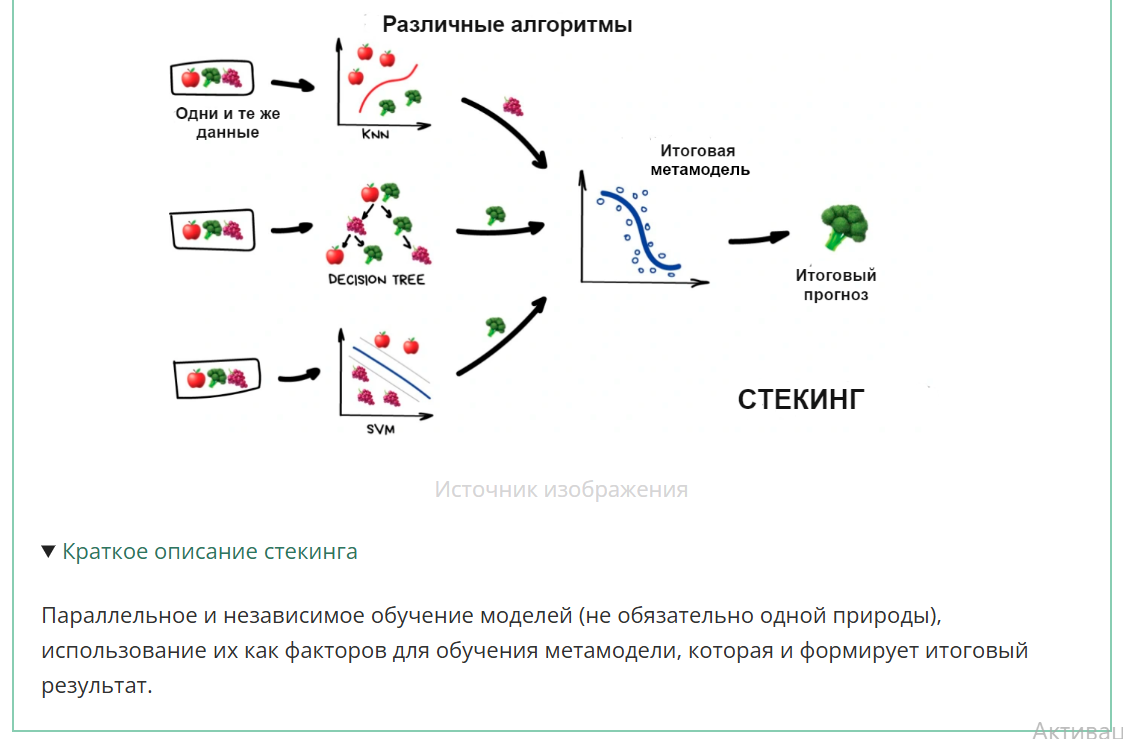

Теперь для каждого ансамбля вы можете:

- объяснить его суть и рассказать про стоящую за ним математическую составляющую;
- применить его для решения задачи классификации и регрессии;
- настроить гиперпараметры ансамбля так, чтобы получить наилучшее качество модели.

Если вы хотите ознакомиться с дополнительными материалами, чтобы ещё больше углубить свои знания, рекомендуем обратить внимание на следующие статьи:

- [О тонкостях настройки гиперпараметров в ансамблях](https://habr.com/ru/post/672486/)

- [О развитии ансамблевых методов машинного обучения](https://www.researchgate.net/publication/278019662_Istoria_razvitia_ansamblevyh_metodov_klassifikacii_v_masinnom_obucenii)